In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats

from sklearn.preprocessing import OrdinalEncoder
import missingno as msno
import statsmodels.stats as sms
from sklearn import feature_selection
from sklearn import preprocessing
from sklearn import pipeline
from sklearn import compose
from sklearn import impute
from sklearn import model_selection
from sklearn import decomposition
import wandb
import wave
import os
import time

In [ ]:
data = pd.read_csv("speeddating.csv", na_values='?')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 123 entries, has_null to match
dtypes: float64(57), int64(7), object(59)
memory usage: 7.9+ MB


In [ ]:
data.columns.tolist()
data['has_null'].groupby(data['has_null']).agg("count")

,has_null
has_null,
0,1048
1,7330


In [ ]:
data.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1,female,21.0,27.0,6,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,0,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,1,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',1,...,[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,0,1,female,21.0,23.0,2,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,1,1
4,0,1,female,21.0,24.0,3,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',0,...,[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1,1,1


In [ ]:
data.describe(include='all')

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
count,8378.00000,8378.000000,8378,8283.000000,8274.000000,8378.000000,8378,8315,8305,8378.000000,...,8378,8378,8138.000000,8069.000000,8378,8378,8003.000000,8378.000000,8378.000000,8378.000000
unique,NaN,NaN,2,NaN,NaN,NaN,4,5,5,NaN,...,3,3,NaN,NaN,3,3,NaN,NaN,NaN,NaN
top,NaN,NaN,male,NaN,NaN,NaN,[2-3],European/Caucasian-American,European/Caucasian-American,NaN,...,[0-3],[0-2],NaN,NaN,[6-8],[5-6],NaN,NaN,NaN,NaN
freq,NaN,NaN,4194,NaN,NaN,NaN,2406,4727,4722,NaN,...,7346,4514,NaN,NaN,4827,3199,NaN,NaN,NaN,NaN
mean,0.87491,11.350919,NaN,26.358928,26.364999,4.185605,NaN,NaN,NaN,0.395799,...,NaN,NaN,6.134087,5.207523,NaN,NaN,0.049856,0.419909,0.419551,0.164717
std,0.33084,5.995903,NaN,3.566763,3.563648,4.596171,NaN,NaN,NaN,0.489051,...,NaN,NaN,1.841285,2.129565,NaN,NaN,0.282168,0.493573,0.493515,0.370947
min,0.00000,1.000000,NaN,18.000000,18.000000,0.000000,NaN,NaN,NaN,0.000000,...,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,1.00000,7.000000,NaN,24.000000,24.000000,1.000000,NaN,NaN,NaN,0.000000,...,NaN,NaN,5.000000,4.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
50%,1.00000,11.000000,NaN,26.000000,26.000000,3.000000,NaN,NaN,NaN,0.000000,...,NaN,NaN,6.000000,5.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
75%,1.00000,15.000000,NaN,28.000000,28.000000,5.000000,NaN,NaN,NaN,1.000000,...,NaN,NaN,7.000000,7.000000,NaN,NaN,0.000000,1.000000,1.000000,0.000000


In [ ]:
duplicates = data.duplicated()
data[duplicates].shape[0]

0

In [ ]:
data.isnull().sum().sum()

np.int64(18372)

In [ ]:
# data.dropna(inplace=True)

In [ ]:
data.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1,female,21.0,27.0,6,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,0,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,1,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',1,...,[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,0,1,female,21.0,23.0,2,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,1,1
4,0,1,female,21.0,24.0,3,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',0,...,[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1,1,1


In [ ]:
def remove_outliers(df: pd.DataFrame):
    df_cleaned = df.copy()
    changed_columns = []
    numeric_cols = df.select_dtypes(include=['number']).columns
    for column_name in numeric_cols:
        Q1 = df[column_name].quantile(0.25)
        Q3 = df[column_name].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[column_name] >= Q1 - 1.5 * IQR) & (df[column_name] <= Q3 + 1.5 * IQR)
        df_cleaned[column_name] = df[column_name][mask]
        if mask.sum() < len(df[column_name]):
            changed_columns.append(column_name)
    return df_cleaned, changed_columns

In [ ]:
df_cleaned, changed_columns = remove_outliers(data)

In [ ]:
data.columns.tolist()
data['has_null'].groupby(data['has_null']).agg("count")

,has_null
has_null,
0,1048
1,7330


In [ ]:
changed_columns

['has_null',
 'age',
 'age_o',
 'd_age',
 'importance_same_race',
 'importance_same_religion',
 'pref_o_attractive',
 'pref_o_sincere',
 'pref_o_intelligence',
 'pref_o_funny',
 'pref_o_ambitious',
 'pref_o_shared_interests',
 'attractive_o',
 'sinsere_o',
 'intelligence_o',
 'funny_o',
 'ambitous_o',
 'shared_interests_o',
 'attractive_important',
 'sincere_important',
 'intellicence_important',
 'funny_important',
 'ambtition_important',
 'shared_interests_important',
 'attractive',
 'sincere',
 'intelligence',
 'funny',
 'ambition',
 'attractive_partner',
 'sincere_partner',
 'intelligence_partner',
 'funny_partner',
 'ambition_partner',
 'shared_interests_partner',
 'sports',
 'tvsports',
 'exercise',
 'dining',
 'museums',
 'art',
 'hiking',
 'gaming',
 'clubbing',
 'reading',
 'tv',
 'theater',
 'movies',
 'concerts',
 'music',
 'shopping',
 'yoga',
 'interests_correlate',
 'expected_happy_with_sd_people',
 'expected_num_interested_in_me',
 'expected_num_matches',
 'like',
 'gues

No outliers

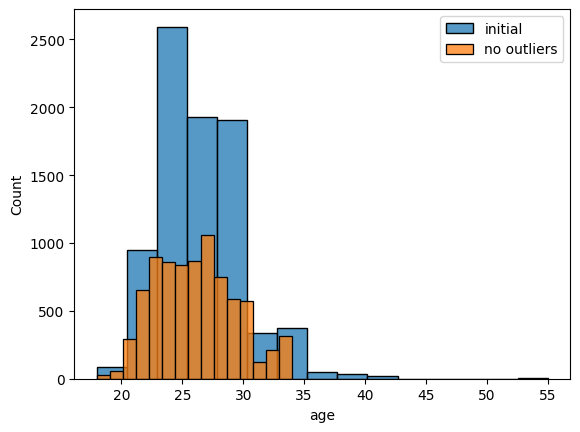

In [ ]:
sns.histplot(x=data['age'], bins=15, label='initial')
sns.histplot(x=df_cleaned['age'], bins=15, label='no outliers')
plt.legend()

<Axes: xlabel='age', ylabel='gender'>

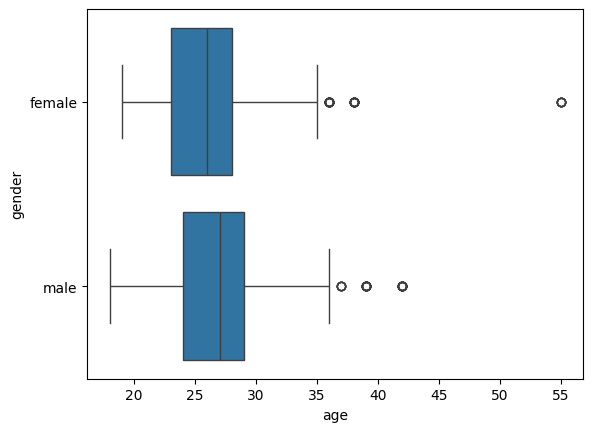

In [ ]:
sns.boxplot(x=data['age'], y=data['gender'])


<Axes: xlabel='age', ylabel='gender'>

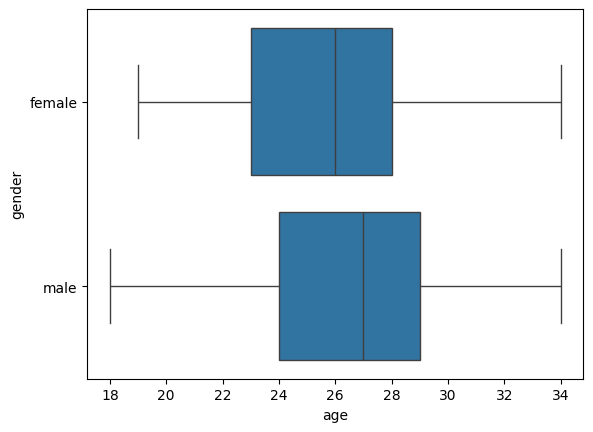

In [ ]:
sns.boxplot(x=df_cleaned['age'], y=df_cleaned['gender'])

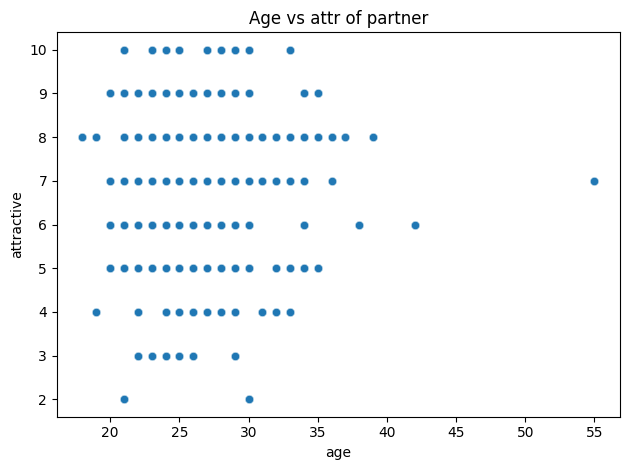

In [ ]:
sns.scatterplot(data=data, x='age', y='attractive', alpha=0.5)
plt.title('Age vs attr of partner')
plt.tight_layout()
plt.show()

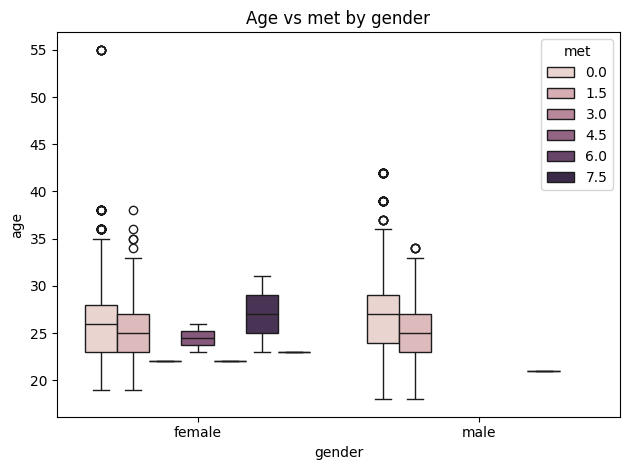

In [ ]:
sns.boxplot(data=data, x='gender', y='age', hue='met')
plt.title('Age vs met by gender')
plt.tight_layout()
plt.show()

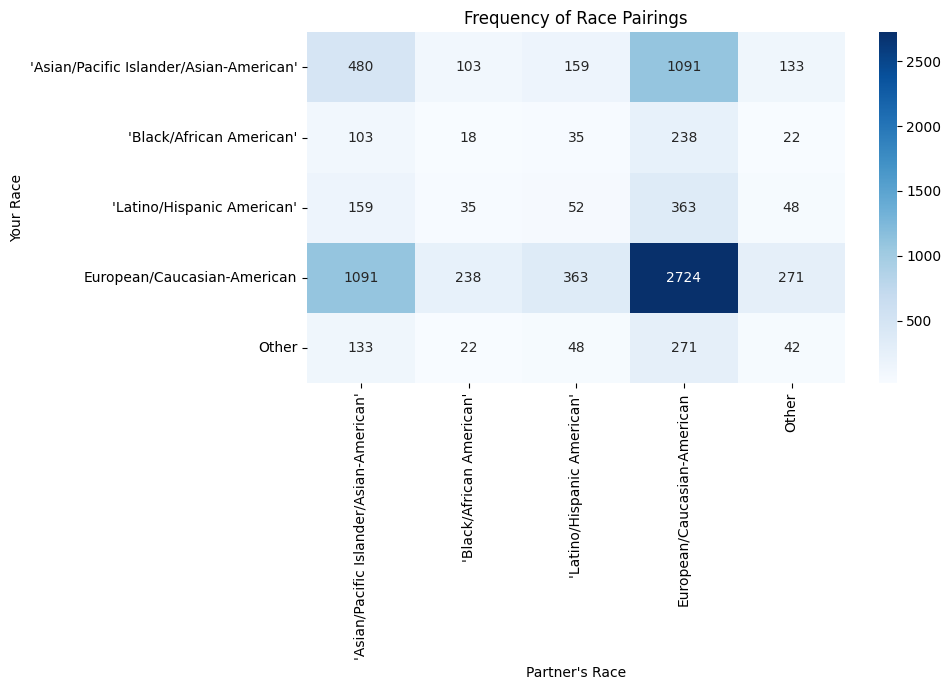

In [ ]:
race_counts = data.groupby(['race', 'race_o']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 7))
sns.heatmap(race_counts, annot=True, fmt='d', cmap='Blues')
plt.title('Frequency of Race Pairings')
plt.xlabel('Partner\'s Race')
plt.ylabel('Your Race')
plt.tight_layout()
plt.show()

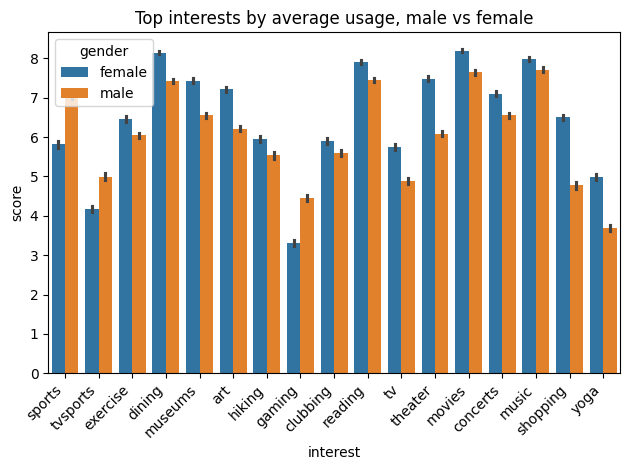

In [ ]:
plot_df = data[
    ["gender"] + [
        'sports',
 'tvsports',
 'exercise',
 'dining',
 'museums',
 'art',
 'hiking',
 'gaming',
 'clubbing',
 'reading',
 'tv',
 'theater',
 'movies',
 'concerts',
 'music',
 'shopping',
 'yoga'
 ]
    ].melt(id_vars="gender", var_name="interest", value_name="score")
plt.figure()
sns.barplot(data=plot_df, x="interest", y="score", hue="gender", estimator=np.mean)
plt.xticks(rotation=45, ha="right")
plt.title("Top interests by average usage, male vs female")
plt.tight_layout()
plt.show()

met and match

In [ ]:
g1= data.groupby("decision")[["met","match"]].mean().reset_index()
g1

,decision,met,match
0,0,0.033735,0.000000
1,1,0.071262,0.392268


In [ ]:
g2 = data.groupby("decision_o")[["met","match"]].mean().reset_index()
g2

,decision_o,met,match
0,0,0.039113,0.000000
1,1,0.064393,0.392603


In [ ]:
g3 = data.groupby(["decision","decision_o"])[["met","match"]].mean().reset_index()
g3

,decision,decision_o,met,match
0,0,0,0.034648,0.0
1,0,1,0.032619,0.0
2,1,0,0.044476,0.0
3,1,1,0.112843,1.0


In [ ]:
na_data = data.isna().sum()
na_percent = (na_data / len(data)) * 100
na_percent[na_percent > 95]

,0


## Analyse Missing Data

<Figure size 1200x600 with 0 Axes>

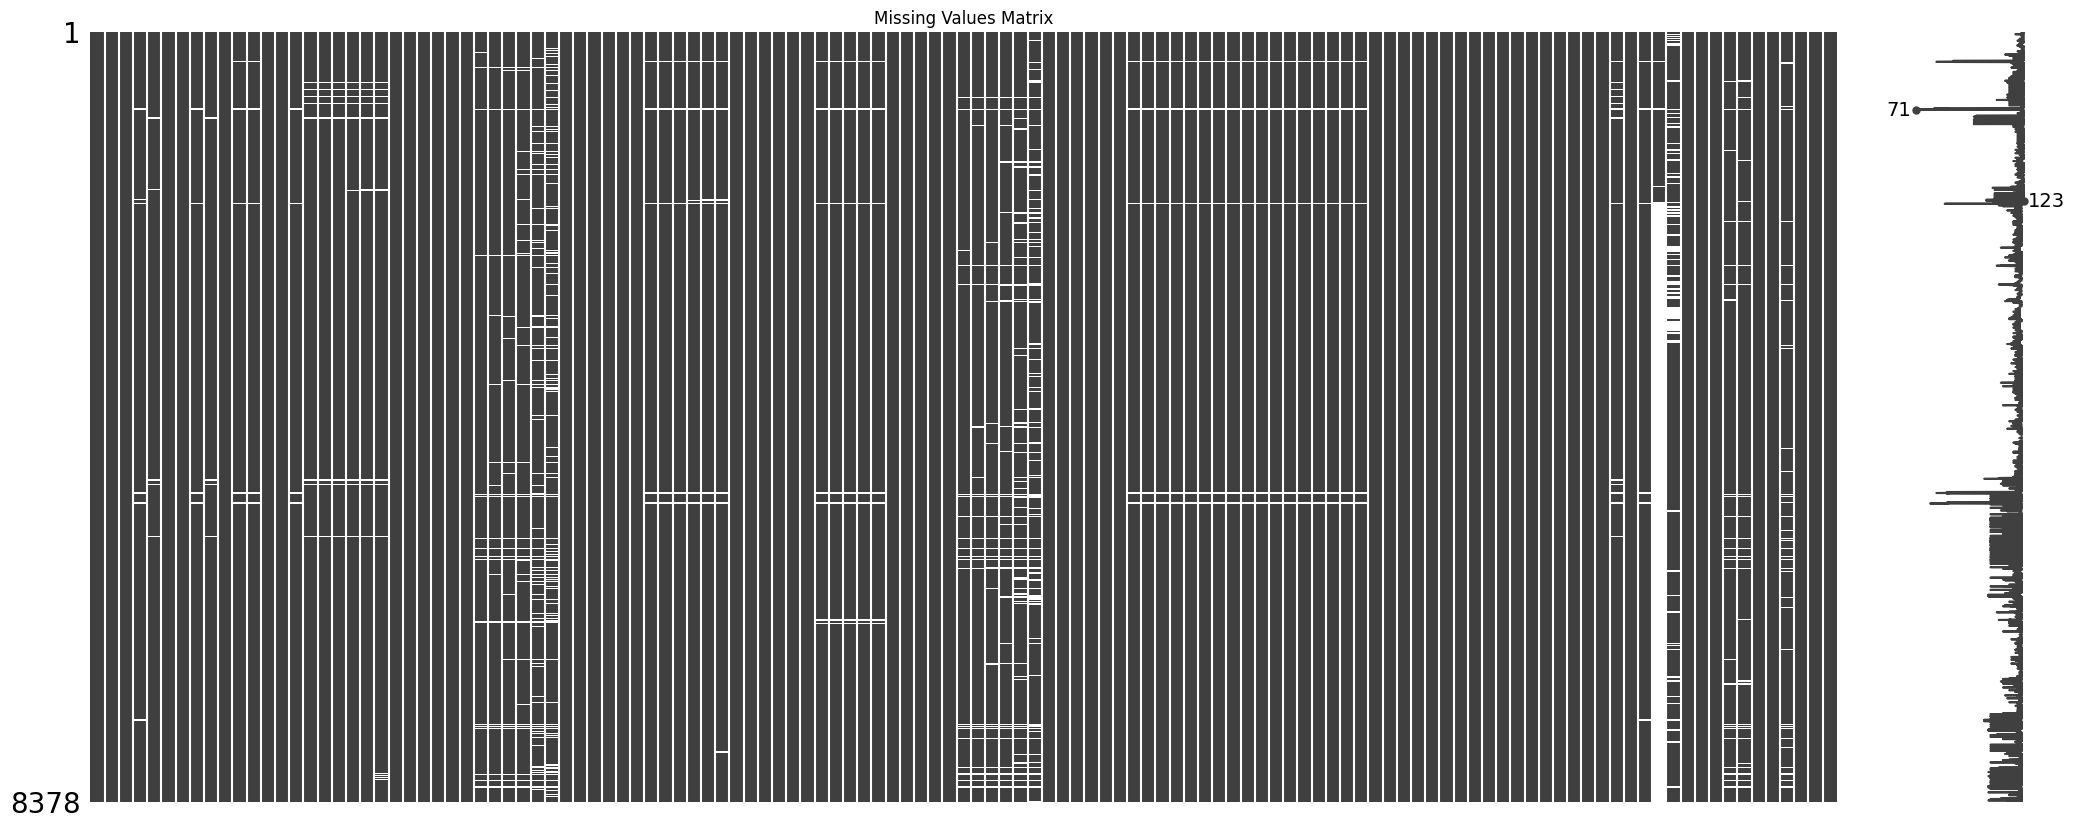

In [ ]:
plt.figure(figsize=(12, 6))
msno.matrix(data)
plt.title('Missing Values Matrix')
plt.show()

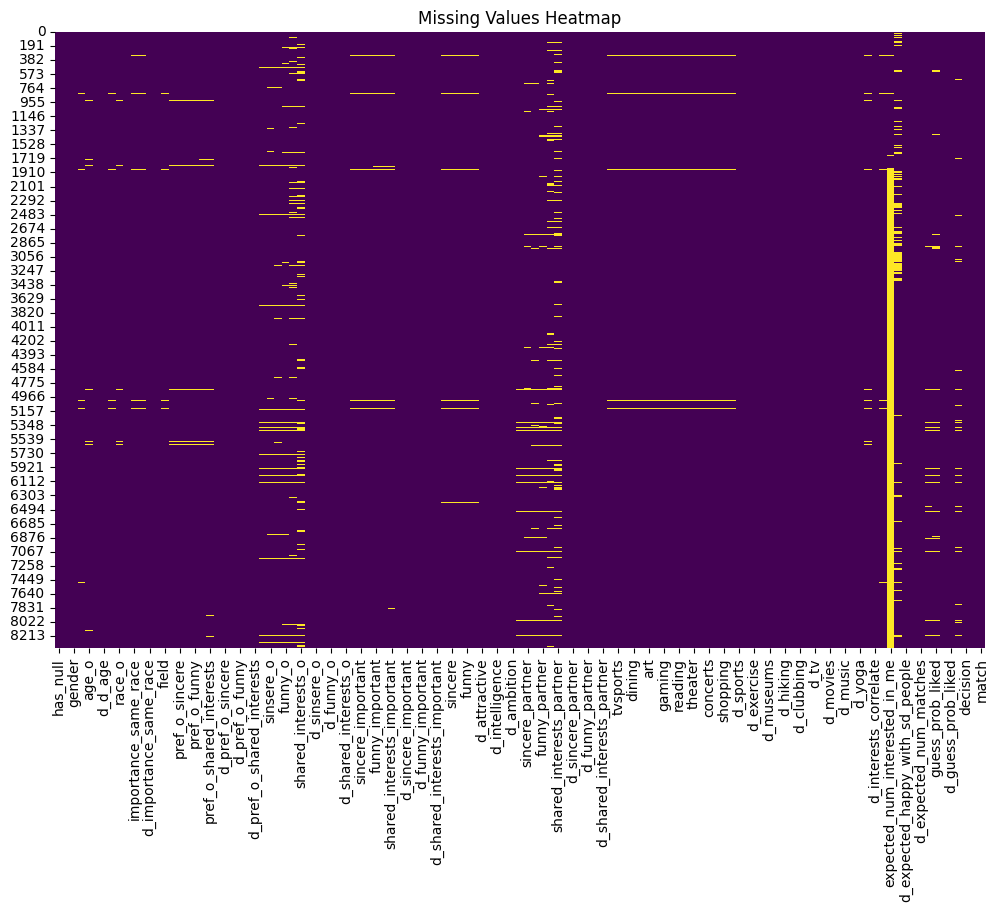

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

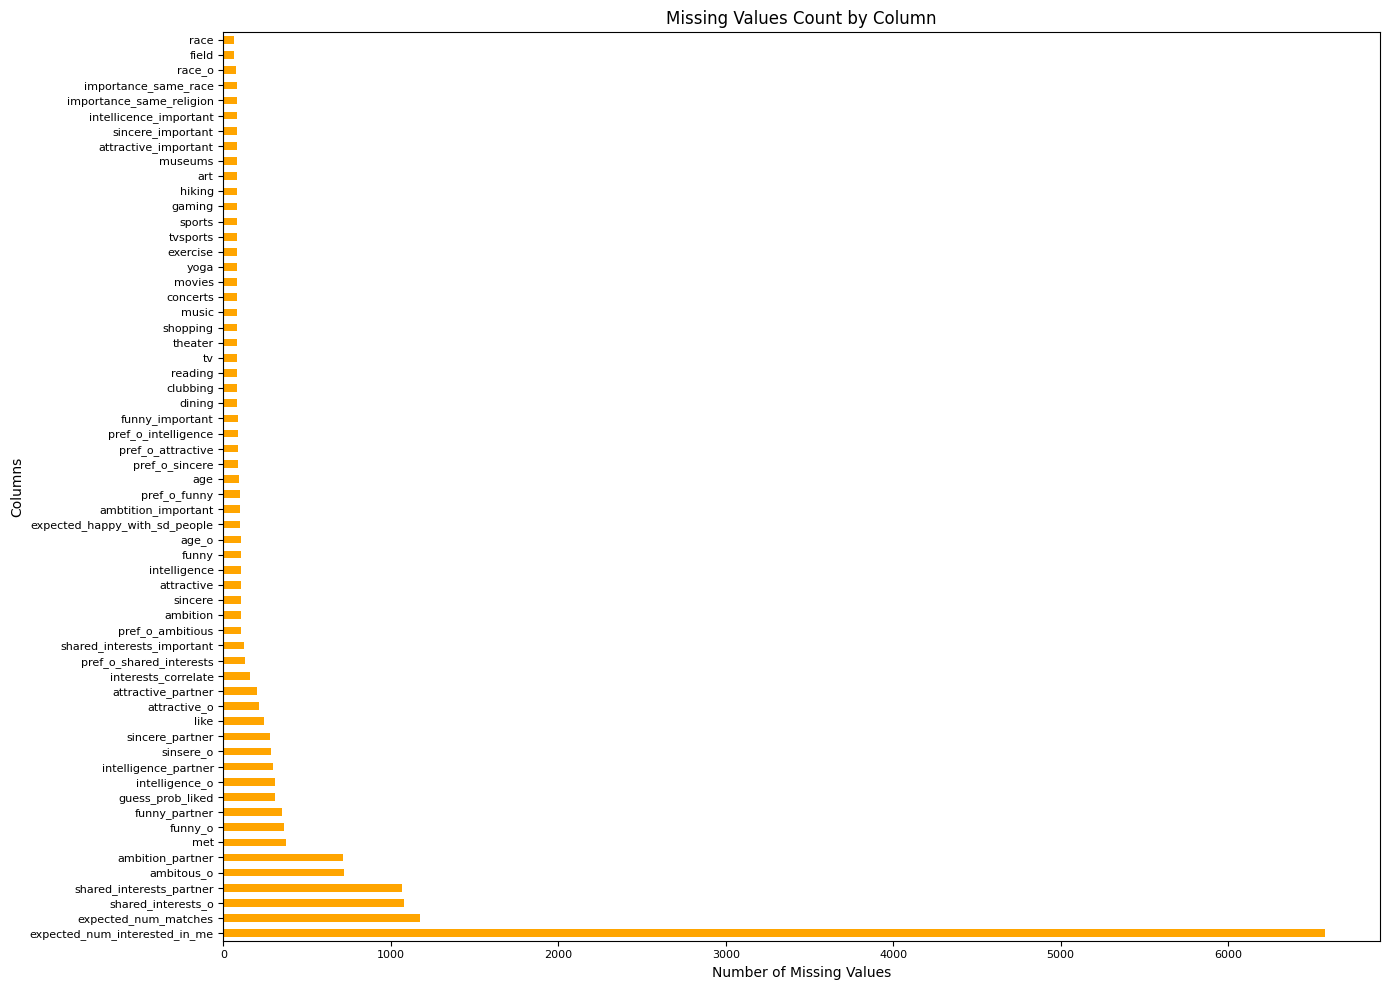

In [ ]:
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(inplace=True)

plt.figure(figsize=(14, 10))
missing_values.plot(kind='barh', color='orange')
plt.title('Missing Values Count by Column', fontsize=12)
plt.xlabel('Number of Missing Values', fontsize=10)
plt.ylabel('Columns', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

there is a big number of missing values in the column expected_num_interests_in_me. Additionally, we did not find any relation to this missigness, so we assume to drop it

In [ ]:
data.drop(columns=['expected_num_interested_in_me'], inplace=True)

returning to the patterns of missigness, it is seem, that there is MAR missigness. We see, that some data can be missed by the 80% of the string, but some occured just randomly. We consider to use imputation MICE algorithm for dealing with missing data

In [ ]:
def get_missing_columns(df, columns_type):
  columns = df.select_dtypes(include=columns_type)
  has_missing_mask = columns.isnull().any()
  missing_columns = has_missing_mask[has_missing_mask].index.tolist()
  return missing_columns

In [ ]:
numerical_missing_columns = get_missing_columns(data, ['number'])
categorical_missing_values = get_missing_columns(data, ['object', 'string'])

print(f"Numerical missing values: {numerical_missing_columns}")
print(f"Categorical missing values: {categorical_missing_values}")

Numerical missing values: ['age', 'age_o', 'importance_same_race', 'importance_same_religion', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'interests_correlate', 'expected_happy_with_sd_people', 'expected_num_matches', 'like', 'guess_prob_liked', 'met']
Categorical missing values: ['race', 'race_o', 'field']


## Analyse categorical data

In [ ]:
categorical_columns = data.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index(['gender', 'd_d_age', 'race', 'race_o', 'd_importance_same_race',
       'd_importance_same_religion', 'field', 'd_pref_o_attractive',
       'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny',
       'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'd_attractive_o',
       'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o',
       'd_shared_interests_o', 'd_attractive_important', 'd_sincere_important',
       'd_intellicence_important', 'd_funny_important',
       'd_ambtition_important', 'd_shared_interests_important', 'd_attractive',
       'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition',
       'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner',
       'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner',
       'd_sports', 'd_tvsports', 'd_exercise', 'd_dining', 'd_museums',
       'd_art', 'd_hiking', 'd_gaming', 'd_clubbing', 'd_reading', 'd_tv',
       'd_theater', 'd_movies', 'd_concerts', 'd_music', 'd_

### Columns cleaning

We found out, that there are the main parameters, that are observed in the dataset which are:\
intelligence, attractive, sincere, funny, ambition, shared_interests

I noticed the errors in some namings. So in this section we will transform the namings to fit the names and for the easier namings

In [ ]:
parameters = ["intelligence", "attractive", "sincere", "funny", "ambition", "shared_interests"]

In [ ]:
unified_parameters = {}
for param in parameters:
  param_correlations = []
  partner_param_importance = f"pref_o_{param}"
  my_param_importance = f"{param}_important"
  partner_param_evaluation = f"{param}_o"
  my_param_evaluation = f"{param}_partner"
  params = [partner_param_importance, my_param_importance, partner_param_evaluation, my_param_evaluation]
  unified_parameters[param] = params

  for p in params:
      if p not in data.columns:
          print(f"Column {p} not found in data.")

Column intelligence_important not found in data.
Column sincere_o not found in data.
Column pref_o_ambition not found in data.
Column ambition_important not found in data.
Column ambition_o not found in data.


In [ ]:
unified_d_parameters = {}
for param in parameters:
  param_correlations = []
  partner_param_importance = f"d_pref_o_{param}"
  my_param_importance = f"d_{param}_important"
  partner_param_evaluation = f"d_{param}_o"
  my_param_evaluation = f"d_{param}_partner"
  params = [partner_param_importance, my_param_importance, partner_param_evaluation, my_param_evaluation]
  unified_d_parameters[param] = params

  for p in params:
      if p not in data.columns:
          print(f"Column {p} not found in data.")

Column d_intelligence_important not found in data.
Column d_sincere_o not found in data.
Column d_pref_o_ambition not found in data.
Column d_ambition_important not found in data.
Column d_ambition_o not found in data.


In [ ]:
cleaned_df = data.copy()
cleaned_df = cleaned_df.rename(columns={
  "intellicence_important": "intelligence_important",
  "d_intellicence_important": "d_intelligence_important",
  "sinsere_o": "sincere_o",
  "d_sinsere_o": "d_sincere_o",
  "pref_o_ambitious": "pref_o_ambition",
  "d_pref_o_ambitious": "d_pref_o_ambition",
  "ambtition_important": "ambition_important",
  "d_ambtition_important": "d_ambition_important",
  "ambitous_o": "ambition_o",
  "d_ambitous_o": "d_ambition_o",
})

cleaned_df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1,female,21.0,27.0,6,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,0,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,1,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',1,...,[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,0,1,female,21.0,23.0,2,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,1,1
4,0,1,female,21.0,24.0,3,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',0,...,[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1,1,1


We cleaned the columns naming, now we will reame them to be easier for understanding

In [ ]:
def rename_to_prefered_name(df, column_name, prefered_name):
    df.rename(columns={column_name: prefered_name}, inplace=True)

In [ ]:
unified_parameters = {}
for param in parameters:
  rename_to_prefered_name(cleaned_df, f"pref_o_{param}", f"{param}_important_o")
  rename_to_prefered_name(cleaned_df, f"{param}_o", f"p_eval_of_my_{param}")
  rename_to_prefered_name(cleaned_df, f"{param}_partner", f"my_eval_of_p_{param}")
  partner_param_importance = f"{param}_important_o"
  my_param_importance = f"{param}_important"
  partner_param_evaluation = f"p_eval_of_my_{param}"
  my_param_evaluation = f"my_eval_of_p_{param}"
  params = [partner_param_importance, my_param_importance, partner_param_evaluation, my_param_evaluation]
  unified_parameters[param] = params

unified_parameters

{'intelligence': ['intelligence_important_o',
  'intelligence_important',
  'p_eval_of_my_intelligence',
  'my_eval_of_p_intelligence'],
 'attractive': ['attractive_important_o',
  'attractive_important',
  'p_eval_of_my_attractive',
  'my_eval_of_p_attractive'],
 'sincere': ['sincere_important_o',
  'sincere_important',
  'p_eval_of_my_sincere',
  'my_eval_of_p_sincere'],
 'funny': ['funny_important_o',
  'funny_important',
  'p_eval_of_my_funny',
  'my_eval_of_p_funny'],
 'ambition': ['ambition_important_o',
  'ambition_important',
  'p_eval_of_my_ambition',
  'my_eval_of_p_ambition'],
 'shared_interests': ['shared_interests_important_o',
  'shared_interests_important',
  'p_eval_of_my_shared_interests',
  'my_eval_of_p_shared_interests']}

In [ ]:
unified_d_parameters = {}

for param in parameters:
  rename_to_prefered_name(cleaned_df, f"d_pref_o_{param}", f"d_{param}_important_o")
  rename_to_prefered_name(cleaned_df, f"d_{param}_o", f"d_p_eval_of_my_{param}")
  rename_to_prefered_name(cleaned_df, f"d_{param}_partner", f"d_my_eval_of_p_{param}")
  partner_param_importance = f"d_{param}_important_o"
  my_param_importance = f"d_{param}_important"
  partner_param_evaluation = f"d_p_eval_of_my_{param}"
  my_param_evaluation = f"d_my_eval_of_p_{param}"
  params = [partner_param_importance, my_param_importance, partner_param_evaluation, my_param_evaluation]
  unified_d_parameters[param] = params

unified_d_parameters

{'intelligence': ['d_intelligence_important_o',
  'd_intelligence_important',
  'd_p_eval_of_my_intelligence',
  'd_my_eval_of_p_intelligence'],
 'attractive': ['d_attractive_important_o',
  'd_attractive_important',
  'd_p_eval_of_my_attractive',
  'd_my_eval_of_p_attractive'],
 'sincere': ['d_sincere_important_o',
  'd_sincere_important',
  'd_p_eval_of_my_sincere',
  'd_my_eval_of_p_sincere'],
 'funny': ['d_funny_important_o',
  'd_funny_important',
  'd_p_eval_of_my_funny',
  'd_my_eval_of_p_funny'],
 'ambition': ['d_ambition_important_o',
  'd_ambition_important',
  'd_p_eval_of_my_ambition',
  'd_my_eval_of_p_ambition'],
 'shared_interests': ['d_shared_interests_important_o',
  'd_shared_interests_important',
  'd_p_eval_of_my_shared_interests',
  'd_my_eval_of_p_shared_interests']}

In [ ]:
print(cleaned_df.columns.tolist())

['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'attractive_important_o', 'sincere_important_o', 'intelligence_important_o', 'funny_important_o', 'ambition_important_o', 'shared_interests_important_o', 'd_attractive_important_o', 'd_sincere_important_o', 'd_intelligence_important_o', 'd_funny_important_o', 'd_ambition_important_o', 'd_shared_interests_important_o', 'p_eval_of_my_attractive', 'p_eval_of_my_sincere', 'p_eval_of_my_intelligence', 'p_eval_of_my_funny', 'p_eval_of_my_ambition', 'p_eval_of_my_shared_interests', 'd_p_eval_of_my_attractive', 'd_p_eval_of_my_sincere', 'd_p_eval_of_my_intelligence', 'd_p_eval_of_my_funny', 'd_p_eval_of_my_ambition', 'd_p_eval_of_my_shared_interests', 'attractive_important', 'sincere_important', 'intelligence_important', 'funny_important', 'ambition_important', 'shared_interests_impo

In [ ]:
for param in parameters:
    cols = unified_parameters[param]
    for col in cols:
        missing_values_count = cleaned_df[cleaned_df[col].isna()].shape[0]
        percentage_missing = (missing_values_count / len(cleaned_df)) * 100
        print(f"{col}: {missing_values_count} missing values; {percentage_missing:.2f}%")

intelligence_important_o: 89 missing values; 1.06%
intelligence_important: 79 missing values; 0.94%
p_eval_of_my_intelligence: 306 missing values; 3.65%
my_eval_of_p_intelligence: 296 missing values; 3.53%
attractive_important_o: 89 missing values; 1.06%
attractive_important: 79 missing values; 0.94%
p_eval_of_my_attractive: 212 missing values; 2.53%
my_eval_of_p_attractive: 202 missing values; 2.41%
sincere_important_o: 89 missing values; 1.06%
sincere_important: 79 missing values; 0.94%
p_eval_of_my_sincere: 287 missing values; 3.43%
my_eval_of_p_sincere: 277 missing values; 3.31%
funny_important_o: 98 missing values; 1.17%
funny_important: 89 missing values; 1.06%
p_eval_of_my_funny: 360 missing values; 4.30%
my_eval_of_p_funny: 350 missing values; 4.18%
ambition_important_o: 107 missing values; 1.28%
ambition_important: 99 missing values; 1.18%
p_eval_of_my_ambition: 722 missing values; 8.62%
my_eval_of_p_ambition: 712 missing values; 8.50%
shared_interests_important_o: 129 missing

In [ ]:
threshold = 0.8
min_non_na = int((1 - threshold) * len(cleaned_df.columns))
cleaned_df = cleaned_df.dropna(thresh=min_non_na)

In [ ]:
for param in parameters:
    cols = unified_parameters[param]
    for col in cols:
        missing_values_count = cleaned_df[cleaned_df[col].isna()].shape[0]
        if missing_values_count == 0:
            print(f"{col}: No missing values")
            continue
        percentage_missing = (missing_values_count / len(cleaned_df)) * 100
        print(f"{col}: {missing_values_count} missing values; {percentage_missing:.2f}%")

intelligence_important_o: 89 missing values; 1.06%
intelligence_important: 79 missing values; 0.94%
p_eval_of_my_intelligence: 306 missing values; 3.65%
my_eval_of_p_intelligence: 296 missing values; 3.53%
attractive_important_o: 89 missing values; 1.06%
attractive_important: 79 missing values; 0.94%
p_eval_of_my_attractive: 212 missing values; 2.53%
my_eval_of_p_attractive: 202 missing values; 2.41%
sincere_important_o: 89 missing values; 1.06%
sincere_important: 79 missing values; 0.94%
p_eval_of_my_sincere: 287 missing values; 3.43%
my_eval_of_p_sincere: 277 missing values; 3.31%
funny_important_o: 98 missing values; 1.17%
funny_important: 89 missing values; 1.06%
p_eval_of_my_funny: 360 missing values; 4.30%
my_eval_of_p_funny: 350 missing values; 4.18%
ambition_important_o: 107 missing values; 1.28%
ambition_important: 99 missing values; 1.18%
p_eval_of_my_ambition: 722 missing values; 8.62%
my_eval_of_p_ambition: 712 missing values; 8.50%
shared_interests_important_o: 129 missing

### Check for the data content

In [ ]:
categorical_df = cleaned_df.select_dtypes(include=['object', 'category'])
categorical_df.head()

,gender,d_d_age,race,race_o,d_importance_same_race,d_importance_same_religion,field,d_attractive_important_o,d_sincere_important_o,d_intelligence_important_o,...,d_concerts,d_music,d_shopping,d_yoga,d_interests_correlate,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,d_like,d_guess_prob_liked
0,female,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[16-20],[16-20],...,[9-10],[9-10],[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[5-6]
1,female,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[0-15],[0-15],...,[9-10],[9-10],[6-8],[0-5],[0.33-1],[0-4],[0-3],[3-5],[6-8],[5-6]
2,female,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',[2-5],[2-5],Law,[16-20],[16-20],[16-20],...,[9-10],[9-10],[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[0-4]
3,female,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[0-15],[0-15],...,[9-10],[9-10],[6-8],[0-5],[0.33-1],[0-4],[0-3],[3-5],[6-8],[5-6]
4,female,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',[2-5],[2-5],Law,[21-100],[0-15],[16-20],...,[9-10],[9-10],[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[5-6]


In [ ]:
categorical_columns = categorical_df.columns.tolist()
categorical_columns

['gender',
 'd_d_age',
 'race',
 'race_o',
 'd_importance_same_race',
 'd_importance_same_religion',
 'field',
 'd_attractive_important_o',
 'd_sincere_important_o',
 'd_intelligence_important_o',
 'd_funny_important_o',
 'd_ambition_important_o',
 'd_shared_interests_important_o',
 'd_p_eval_of_my_attractive',
 'd_p_eval_of_my_sincere',
 'd_p_eval_of_my_intelligence',
 'd_p_eval_of_my_funny',
 'd_p_eval_of_my_ambition',
 'd_p_eval_of_my_shared_interests',
 'd_attractive_important',
 'd_sincere_important',
 'd_intelligence_important',
 'd_funny_important',
 'd_ambition_important',
 'd_shared_interests_important',
 'd_attractive',
 'd_sincere',
 'd_intelligence',
 'd_funny',
 'd_ambition',
 'd_my_eval_of_p_attractive',
 'd_my_eval_of_p_sincere',
 'd_my_eval_of_p_intelligence',
 'd_my_eval_of_p_funny',
 'd_my_eval_of_p_ambition',
 'd_my_eval_of_p_shared_interests',
 'd_sports',
 'd_tvsports',
 'd_exercise',
 'd_dining',
 'd_museums',
 'd_art',
 'd_hiking',
 'd_gaming',
 'd_clubbing',
 'd

In [ ]:
categorical_df.nunique()

,0
gender,2
d_d_age,4
race,5
race_o,5
d_importance_same_race,3
d_importance_same_religion,3
field,259
d_attractive_important_o,3
d_sincere_important_o,3
d_intelligence_important_o,3


In [ ]:
cols_unique_values = {}

for col in categorical_df.columns:
    unique_vals = categorical_df[col].unique()
    print(f"{col}: {len(unique_vals)}\n{unique_vals}\n")


gender: 2
['female' 'male']

d_d_age: 4
['[4-6]' '[0-1]' '[2-3]' '[7-37]']

race: 6
["'Asian/Pacific Islander/Asian-American'" 'European/Caucasian-American'
 'Other' "'Latino/Hispanic American'" "'Black/African American'" nan]

race_o: 6
['European/Caucasian-American' "'Asian/Pacific Islander/Asian-American'"
 "'Latino/Hispanic American'" 'Other' "'Black/African American'" nan]

d_importance_same_race: 3
['[2-5]' '[6-10]' '[0-1]']

d_importance_same_religion: 3
['[2-5]' '[0-1]' '[6-10]']

field: 260
['Law' 'law' 'Economics' "'Masters in Public Administration'"
 "'Masters of Social Work&Education'" 'Finance' 'Business'
 "'political science'" 'money' "'Operations Research'" "'TC [Health Ed]'"
 'Psychology' "'social work'" "'Social Work'"
 "'Speech Language Pathology'" "'Speech Languahe Pathology'"
 "'Educational Psychology'" "'Applied Maths/Econs'" 'Mathematics'
 'Statistics' "'Organizational Psychology'" "'Mechanical Engineering'"
 'Finanace' 'Finance&Economics' "'Undergrad - GS'"
 "'Ma

According to the unique values represented for each categorical data field now we can divide them into 4 categorical group types:
1. Nominal data: gender, race, race_o, field (which is probably represent the job of person)
2. Ordinal data: - all the left fields are related to ratio data, since they cannot be less than 0 and represent some intervals. Despite, that these data re represented as ranges-string thay are follow in ascending order, so we can speak about them as ordinal data.

According to the received info we can proceed on working on data by the type of category.

### Nominal data

#### gender

In [ ]:
match_between_genders = cleaned_df.groupby(['match', 'gender']).size().unstack(fill_value=0)
match_between_genders

gender,female,male
match,,
0,3494,3504
1,690,690


In [ ]:
match_percentages = (cleaned_df.groupby(['match', 'gender']).size().unstack(fill_value=0)
                     .div(cleaned_df.groupby('match').size(), axis=0) * 100)
match_percentages

gender,female,male
match,,
0,49.928551,50.071449
1,50.000000,50.000000


<Figure size 1000x600 with 0 Axes>

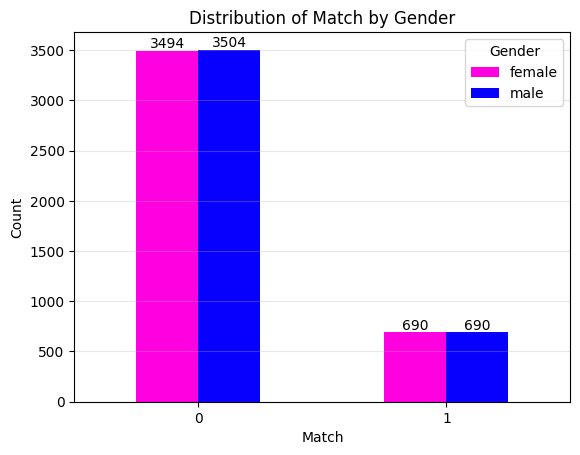

In [ ]:
plt.figure(figsize=(10, 6))
ax = match_between_genders.plot(kind='bar', color=["#FF00E1", "#0800FF"])
plt.title('Distribution of Match by Gender')
plt.xlabel('Match')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, label_type='edge')


plt.show()

<Figure size 1000x600 with 0 Axes>

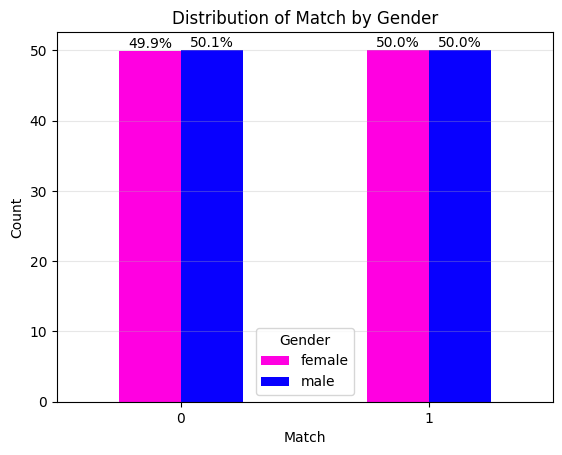

In [ ]:
plt.figure(figsize=(10, 6))
ax = match_percentages.plot(kind='bar', color=["#FF00E1", "#0800FF"])
plt.title('Distribution of Match by Gender')
plt.xlabel('Match')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type='edge')


plt.show()

In [ ]:
gender_encoded = pd.get_dummies(categorical_df, columns=['gender'])
gender_encoded.head()

,d_d_age,race,race_o,d_importance_same_race,d_importance_same_religion,field,d_attractive_important_o,d_sincere_important_o,d_intelligence_important_o,d_funny_important_o,...,d_shopping,d_yoga,d_interests_correlate,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,d_like,d_guess_prob_liked,gender_female,gender_male
0,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[16-20],[16-20],[16-20],...,[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[5-6],True,False
1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[0-15],[0-15],[21-100],...,[6-8],[0-5],[0.33-1],[0-4],[0-3],[3-5],[6-8],[5-6],True,False
2,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',[2-5],[2-5],Law,[16-20],[16-20],[16-20],[16-20],...,[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[0-4],True,False
3,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[0-15],[0-15],[21-100],...,[6-8],[0-5],[0.33-1],[0-4],[0-3],[3-5],[6-8],[5-6],True,False
4,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',[2-5],[2-5],Law,[21-100],[0-15],[16-20],[0-15],...,[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[5-6],True,False


It is clearly seen from the unique values, that we can indicate about 12 types of jobs. We will try to cluster them to unify to some 12 categories for the better processing them in the future model

### Correlations between variables and match

1. Use chi-square test to to determine if there is a significant association between each variable and target(match)
2. On the base of chi-square test result use Cramer's V test to measure the association between each variable and match - calculation of correlations

In [ ]:
def chi_square_test(var1, var2):
    confusion_matrix = pd.crosstab(var1, var2)
    chi2, _, _, _ = stats.chi2_contingency(confusion_matrix)
    return chi2, confusion_matrix

In [ ]:
def cramerV(label, x):
    chi2, confusion_matrix = chi_square_test(label, x)
    n = confusion_matrix.sum().sum()
    minDim = min(confusion_matrix.shape) - 1
    V = np.sqrt((chi2 / n) / minDim)
    return V

In [ ]:
correlation_results = {}

for col in categorical_columns:
    correlation_results[col] = cramerV(cleaned_df['match'], categorical_df[col])

categorical_correlations = pd.DataFrame.from_dict(correlation_results, orient='index', columns=['correlation'])
print(categorical_correlations.sort_values(by='correlation', ascending=False))

                                 correlation
d_like                              0.284973
field                               0.270954
d_p_eval_of_my_funny                0.266513
d_my_eval_of_p_funny                0.265959
d_p_eval_of_my_shared_interests     0.252182
d_my_eval_of_p_shared_interests     0.251825
d_guess_prob_liked                  0.247899
d_p_eval_of_my_attractive           0.243230
d_my_eval_of_p_attractive           0.242683
d_p_eval_of_my_intelligence         0.163777
d_my_eval_of_p_intelligence         0.163058
d_p_eval_of_my_sincere              0.156340
d_my_eval_of_p_sincere              0.155613
d_p_eval_of_my_ambition             0.135391
d_my_eval_of_p_ambition             0.134992
d_expected_num_matches              0.099217
d_clubbing                          0.062272
d_expected_num_interested_in_me     0.061889
d_d_age                             0.059045
d_reading                           0.055784
race                                0.053206
race_o    

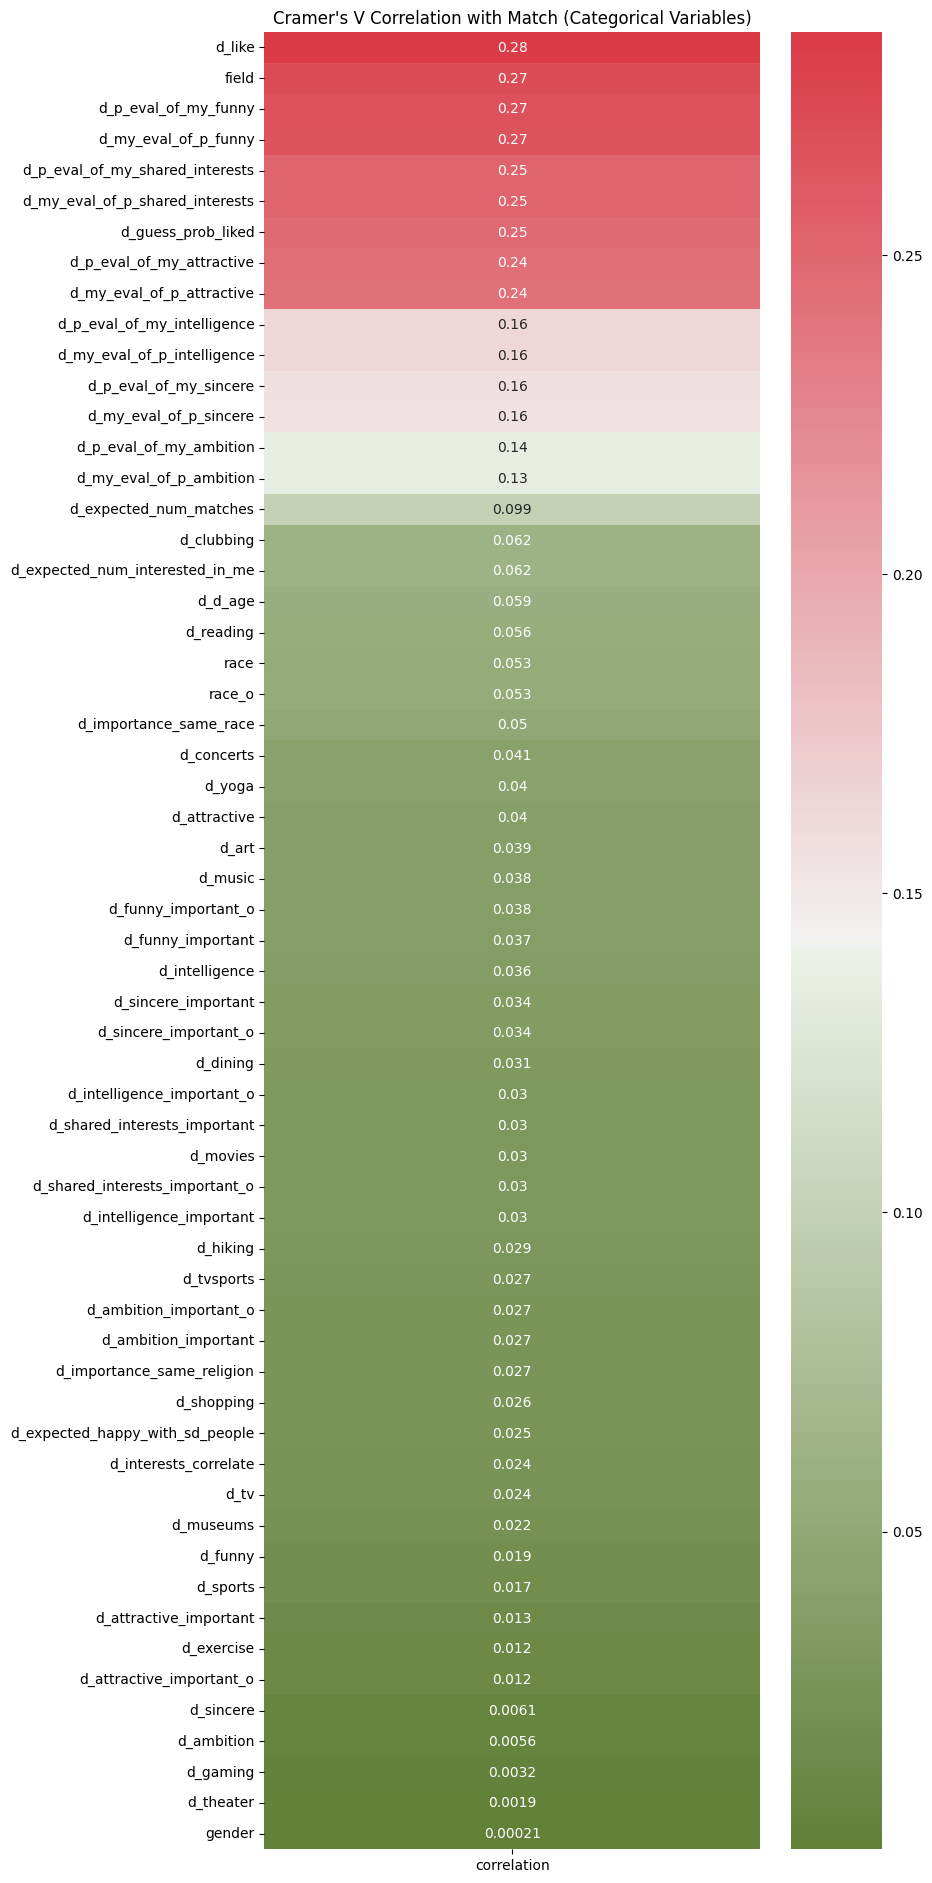

In [ ]:
categorical_correlations_sorted = categorical_correlations.sort_values('correlation', ascending=False)
cmap = sns.diverging_palette(110, 10, as_cmap=True)

n_variables = len(categorical_correlations_sorted)
plt.figure(figsize=(8, max(6, n_variables * 0.4)))
sns.heatmap(categorical_correlations_sorted,
            annot=True,
            cmap=cmap)
plt.title('Cramer\'s V Correlation with Match (Categorical Variables)')
plt.show()

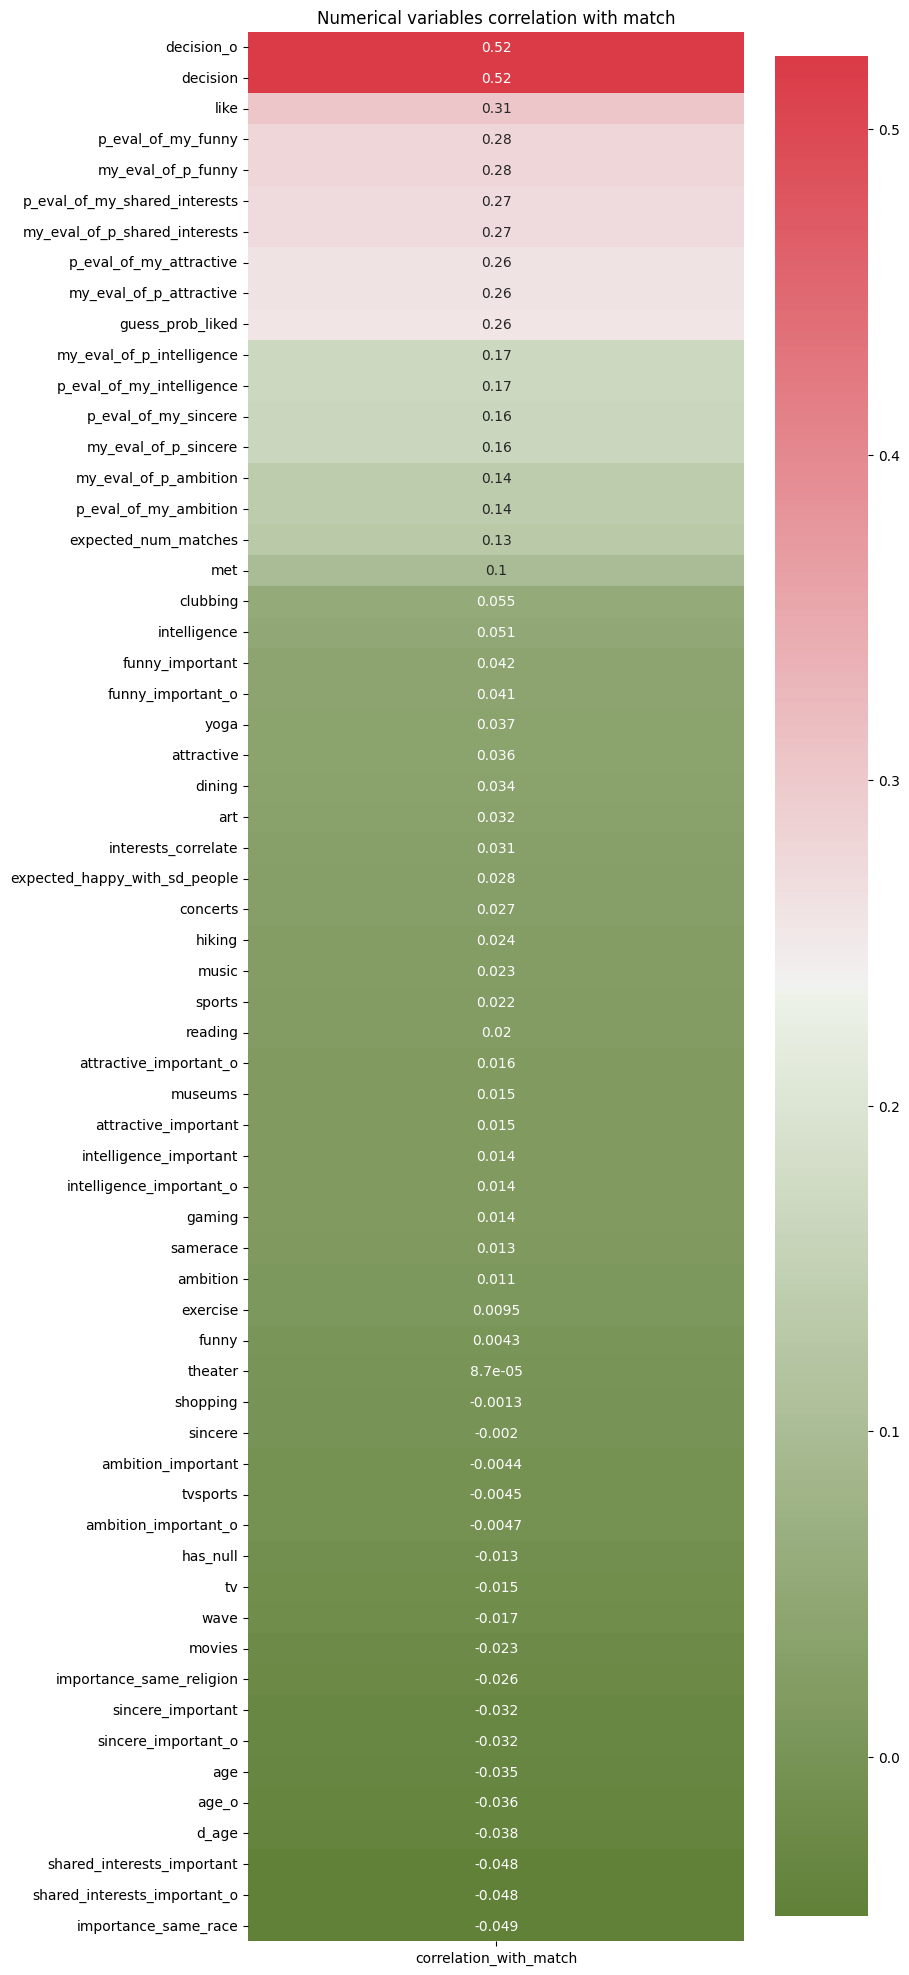

In [ ]:
numeric_columns = cleaned_df.select_dtypes(include=['number']).columns
numeric_corr_match = cleaned_df[numeric_columns].corr()['match'].drop('match').sort_values(ascending=False)
corr_df = numeric_corr_match.to_frame('correlation_with_match')

cmap = sns.diverging_palette(110, 10, as_cmap=True)

n_variables = len(corr_df)
plt.figure(figsize=(8, max(6, n_variables * 0.4)))
sns.heatmap(corr_df,
            annot=True,
            cmap=cmap)
plt.title('Numerical variables correlation with match')
plt.show()

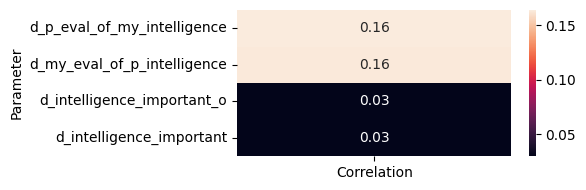

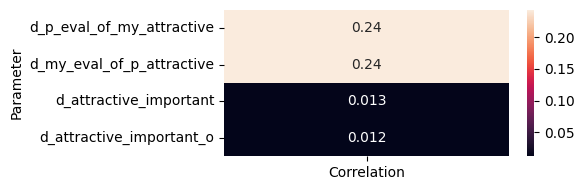

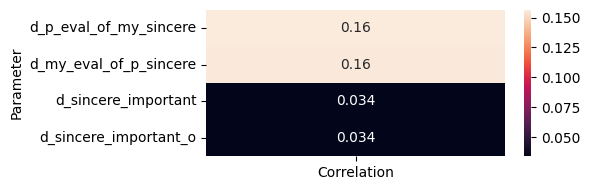

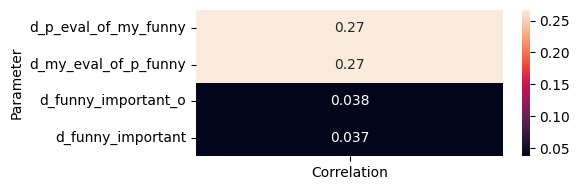

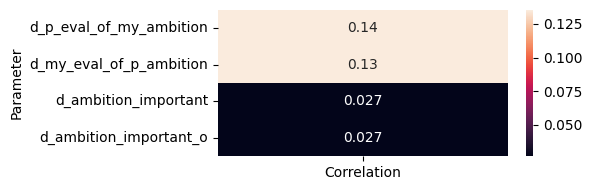

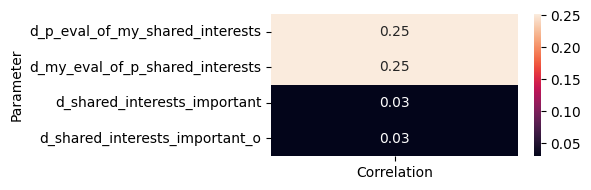

In [ ]:
correlations_total = {}

for param in unified_d_parameters:
    correlations = {}
    correlations_total[param] = []
    for p in unified_d_parameters[param]:
        if p in cleaned_df.columns:
            correlations[p] = cramerV(cleaned_df[p], cleaned_df['match'])
            correlations_total[param].append({p: correlations[p]})

    if correlations:
        plot_df = pd.DataFrame(list(correlations.items()),
                             columns=['Parameter', 'Correlation'])
        plot_df = plot_df.sort_values(by='Correlation', ascending=False)
        plot_df = plot_df.set_index('Parameter')

        plt.figure(figsize=(6, 2))
        sns.heatmap(plot_df,
                    annot=True)
        plt.tight_layout()
        plt.show()

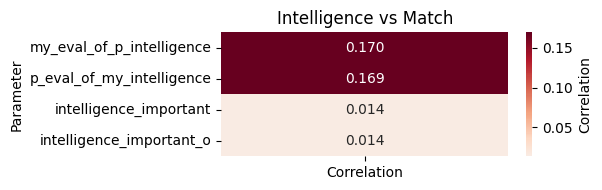

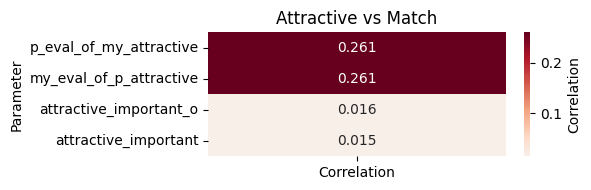

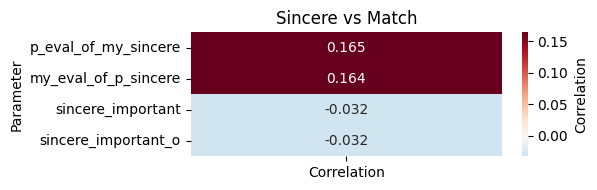

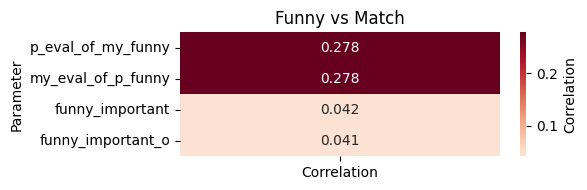

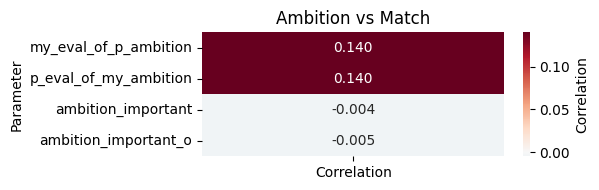

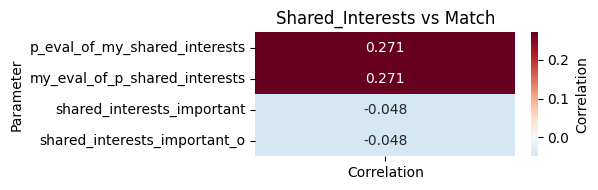

In [ ]:
for param in unified_parameters:
    correlations = {}
    for p in unified_parameters[param]:
        if p in cleaned_df.columns:
            correlations[p] = cleaned_df[p].corr(cleaned_df['match'])
            correlations_total[param].append({p: correlations[p]})

    if correlations:
        plot_df = pd.DataFrame(list(correlations.items()),
                             columns=['Parameter', 'Correlation'])
        plot_df = plot_df.sort_values(by='Correlation', ascending=False)
        plot_df = plot_df.set_index('Parameter')

        plt.figure(figsize=(6, 2))
        sns.heatmap(plot_df,
                    annot=True,
                    center=0,
                    fmt='.3f',
                    cmap='RdBu_r',
                    cbar_kws={'label': 'Correlation'})
        plt.title(f'{param.title()} vs Match')
        plt.tight_layout()
        plt.show()

In [ ]:
correlations_total = {}

for param in correlations_total:
    flat_correlations = {}
    for item in correlations_total[param]:
        flat_correlations.update(item)
    plot_df = pd.DataFrame(list(flat_correlations.items()),
                         columns=['Parameter', 'Correlation'])
    plot_df = plot_df.sort_values(by='Correlation', ascending=False)
    plot_df = plot_df.set_index('Parameter')

    plt.figure(figsize=(6, 4))
    sns.heatmap(plot_df,
                    annot=True)
    plt.title(f'{param.title()} vs Match')
    plt.tight_layout()
    plt.show()

### Correlation between variables in the groups

Since we have the 8 variable for each parameter, half of which represented by d_, which probably means difference, so we consider to check their correlations too. We assume, that d_ and ordinar variables would have high correlation between them, so we can remove half of the variables, since it is not good to add highly correlated variables. That can lead to the overfitting or some other problems.

#### Encoding of categorical variables

All of our d_ variables are represented by string with ranges, that follows ascending order. Since there is no method, that would calculate the correlaition vetween the string-range categorical variable and numerical one, we consider to encode each ranges variable

In [ ]:
for param in unified_d_parameters.values():
  for p in param:
    unique_values = sorted(cleaned_df[p].unique())
    print(f"{p}: {unique_values}")
  print()

d_intelligence_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_intelligence_important: ['[0-15]', '[16-20]', '[21-100]']
d_p_eval_of_my_intelligence: ['[0-5]', '[6-8]', '[9-10]']
d_my_eval_of_p_intelligence: ['[0-5]', '[6-8]', '[9-10]']

d_attractive_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_attractive_important: ['[0-15]', '[16-20]', '[21-100]']
d_p_eval_of_my_attractive: ['[0-5]', '[6-8]', '[9-10]']
d_my_eval_of_p_attractive: ['[0-5]', '[6-8]', '[9-10]']

d_sincere_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_sincere_important: ['[0-15]', '[16-20]', '[21-100]']
d_p_eval_of_my_sincere: ['[0-5]', '[6-8]', '[9-10]']
d_my_eval_of_p_sincere: ['[0-5]', '[6-8]', '[9-10]']

d_funny_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_funny_important: ['[0-15]', '[16-20]', '[21-100]']
d_p_eval_of_my_funny: ['[0-5]', '[6-8]', '[9-10]']
d_my_eval_of_p_funny: ['[0-5]', '[6-8]', '[9-10]']

d_ambition_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_ambition_important: ['[0-15]', '[16-20]'

In [ ]:
encoder1 = OrdinalEncoder(categories=[['[0-15]', '[16-20]', '[21-100]']])
encoder2 = OrdinalEncoder(categories=[['[0-5]', '[6-8]', '[9-10]']])

for param in parameters:
  cleaned_df[f"d_{param}_important_o"] = encoder1.fit_transform(cleaned_df[[f"d_{param}_important_o"]])
  cleaned_df[f"d_{param}_important"] = encoder1.fit_transform(cleaned_df[[f"d_{param}_important"]])
  cleaned_df[f"d_p_eval_of_my_{param}"] = encoder2.fit_transform(cleaned_df[[f"d_p_eval_of_my_{param}"]])
  cleaned_df[f"d_my_eval_of_p_{param}"] = encoder2.fit_transform(cleaned_df[[f"d_my_eval_of_p_{param}"]])

In [ ]:
for param in unified_d_parameters.values():
  for p in param:
    unique_values = sorted(cleaned_df[p].unique())
    print(f"{p}: {unique_values}")
  print()

d_intelligence_important_o: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_intelligence_important: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_p_eval_of_my_intelligence: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_my_eval_of_p_intelligence: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

d_attractive_important_o: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_attractive_important: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_p_eval_of_my_attractive: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_my_eval_of_p_attractive: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

d_sincere_important_o: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_sincere_important: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_p_eval_of_my_sincere: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_my_eval_of_p_sincere: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

d_funny_important_o: [np.float64(0.0), np.float64(1.0), np.float6

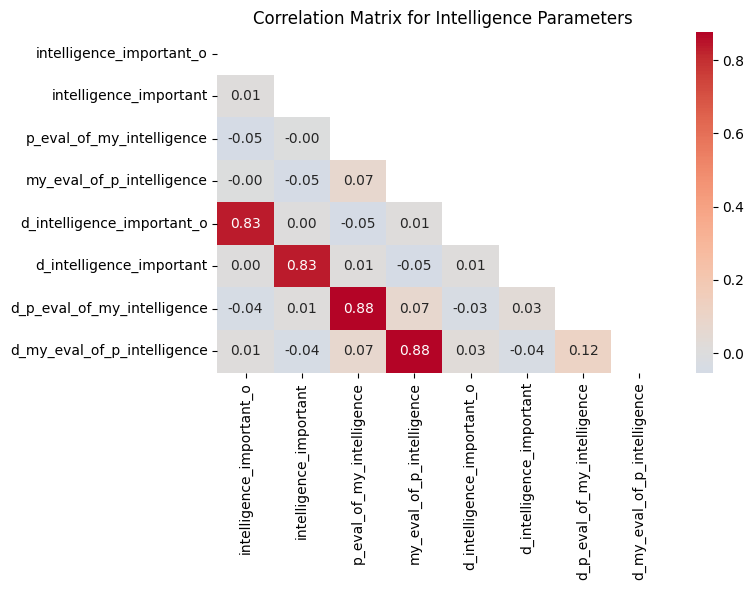

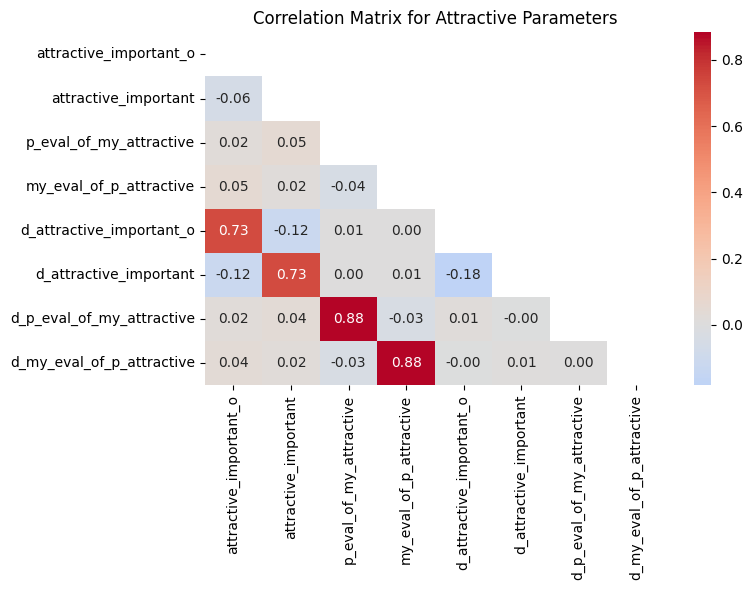

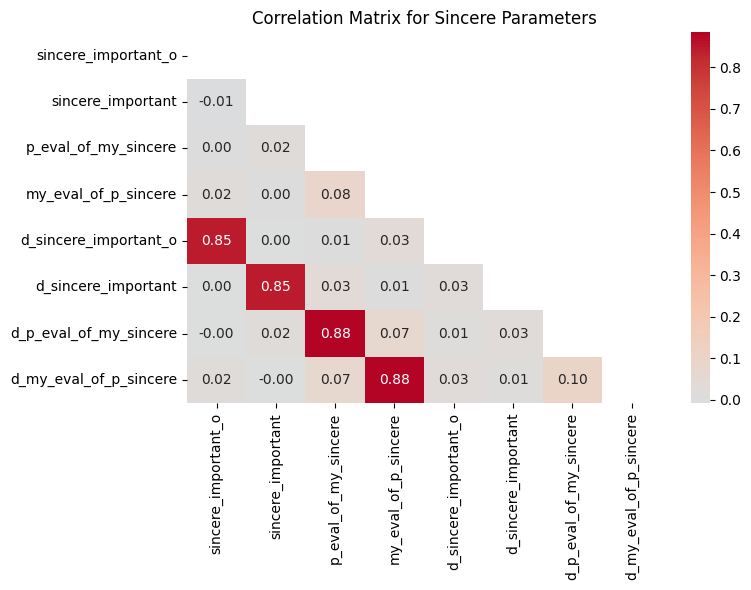

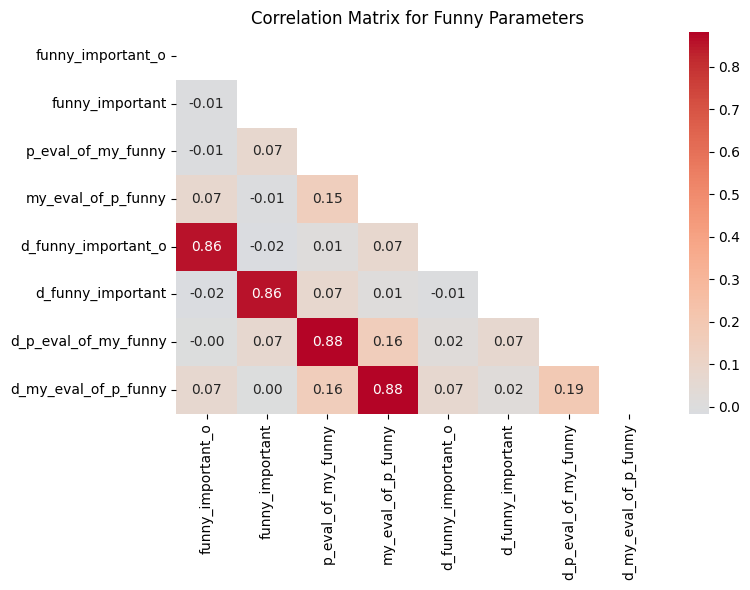

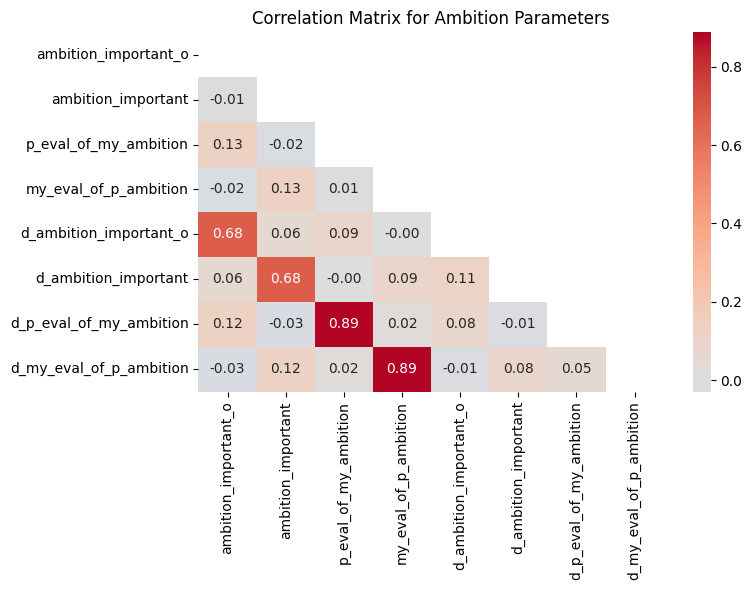

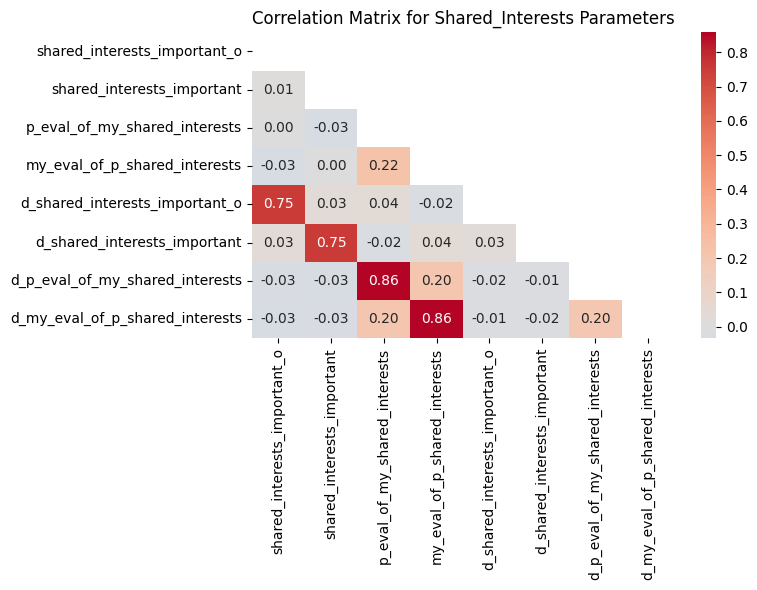

In [ ]:
for param in parameters:
  selected_group_columns = []
  selected_group_columns += unified_parameters[param]
  selected_group_columns += unified_d_parameters[param]

  corr_matrix = cleaned_df[selected_group_columns].corr()
  plt.figure(figsize=(8, 6))
  mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
  sns.heatmap(corr_matrix, annot=True, mask=mask, fmt='.2f', cmap='coolwarm', center=0)
  plt.title(f'Correlation Matrix for {param.title()} Parameters')
  plt.tight_layout()
  plt.show()

The theory about the d_ variables and the ordinary one was supported by correlation heatmaps. Each 2 pairs of veriable have high correlation, so we will drop all the variables, represented as d_ variables.The data are represented in more obscure format, which we cannot say with certainty what define.

In [ ]:
for param in unified_d_parameters.values():
  cleaned_df.drop(columns=param, inplace=True)

print(cleaned_df.columns.tolist())

['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'attractive_important_o', 'sincere_important_o', 'intelligence_important_o', 'funny_important_o', 'ambition_important_o', 'shared_interests_important_o', 'p_eval_of_my_attractive', 'p_eval_of_my_sincere', 'p_eval_of_my_intelligence', 'p_eval_of_my_funny', 'p_eval_of_my_ambition', 'p_eval_of_my_shared_interests', 'attractive_important', 'sincere_important', 'intelligence_important', 'funny_important', 'ambition_important', 'shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition', 'my_eval_of_p_attractive', 'my_eval_of_p_sincere', 'my_eval_of_p_intelligence', 'my_eval_of_p_funny', 'my_eval_of_p_ambition', 'my_eval_of_p_shared_interests', 'sports', 'tvsports', 'exercise', 'd

### Clean columns

During analysis we also mentioned, that there are many hobbies and d_hobbies variables, which could easily be replaced with interests_correlate and d_interests_correlate. So we will drop them too

In [ ]:
interests_columns = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'd_sports', 'd_tvsports', 'd_exercise', 'd_dining', 'd_museums', 'd_art', 'd_hiking', 'd_gaming', 'd_clubbing', 'd_reading', 'd_tv', 'd_theater', 'd_movies', 'd_concerts', 'd_music', 'd_shopping', 'd_yoga']
cleaned_df.drop(columns=interests_columns, inplace=True)

print(cleaned_df.columns.tolist())

['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'attractive_important_o', 'sincere_important_o', 'intelligence_important_o', 'funny_important_o', 'ambition_important_o', 'shared_interests_important_o', 'p_eval_of_my_attractive', 'p_eval_of_my_sincere', 'p_eval_of_my_intelligence', 'p_eval_of_my_funny', 'p_eval_of_my_ambition', 'p_eval_of_my_shared_interests', 'attractive_important', 'sincere_important', 'intelligence_important', 'funny_important', 'ambition_important', 'shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition', 'my_eval_of_p_attractive', 'my_eval_of_p_sincere', 'my_eval_of_p_intelligence', 'my_eval_of_p_funny', 'my_eval_of_p_ambition', 'my_eval_of_p_shared_interests', 'interests_correlate', 'd_interests_

In [ ]:
def plot_distributions(df):
  columns = df.select_dtypes(include=['number']).columns.tolist()

  col_num = 3
  row_num = math.ceil(len(columns) / col_num)

  _, axes = plt.subplots(nrows = row_num, ncols = col_num, figsize=(20, 4 * row_num))
  axes = axes.flatten()

  for i, col in enumerate(columns):
      sns.histplot(df[col], ax=axes[i], linewidth=0.3)
      axes[i].set_title(f'Distribution of {col}', fontsize=8)
      axes[i].set_xlabel(col, fontsize=8)
      axes[i].set_ylabel("Count", fontsize=8)

  plt.subplots_adjust(hspace=0.75, wspace=0.3)
  plt.tight_layout()
  plt.show()

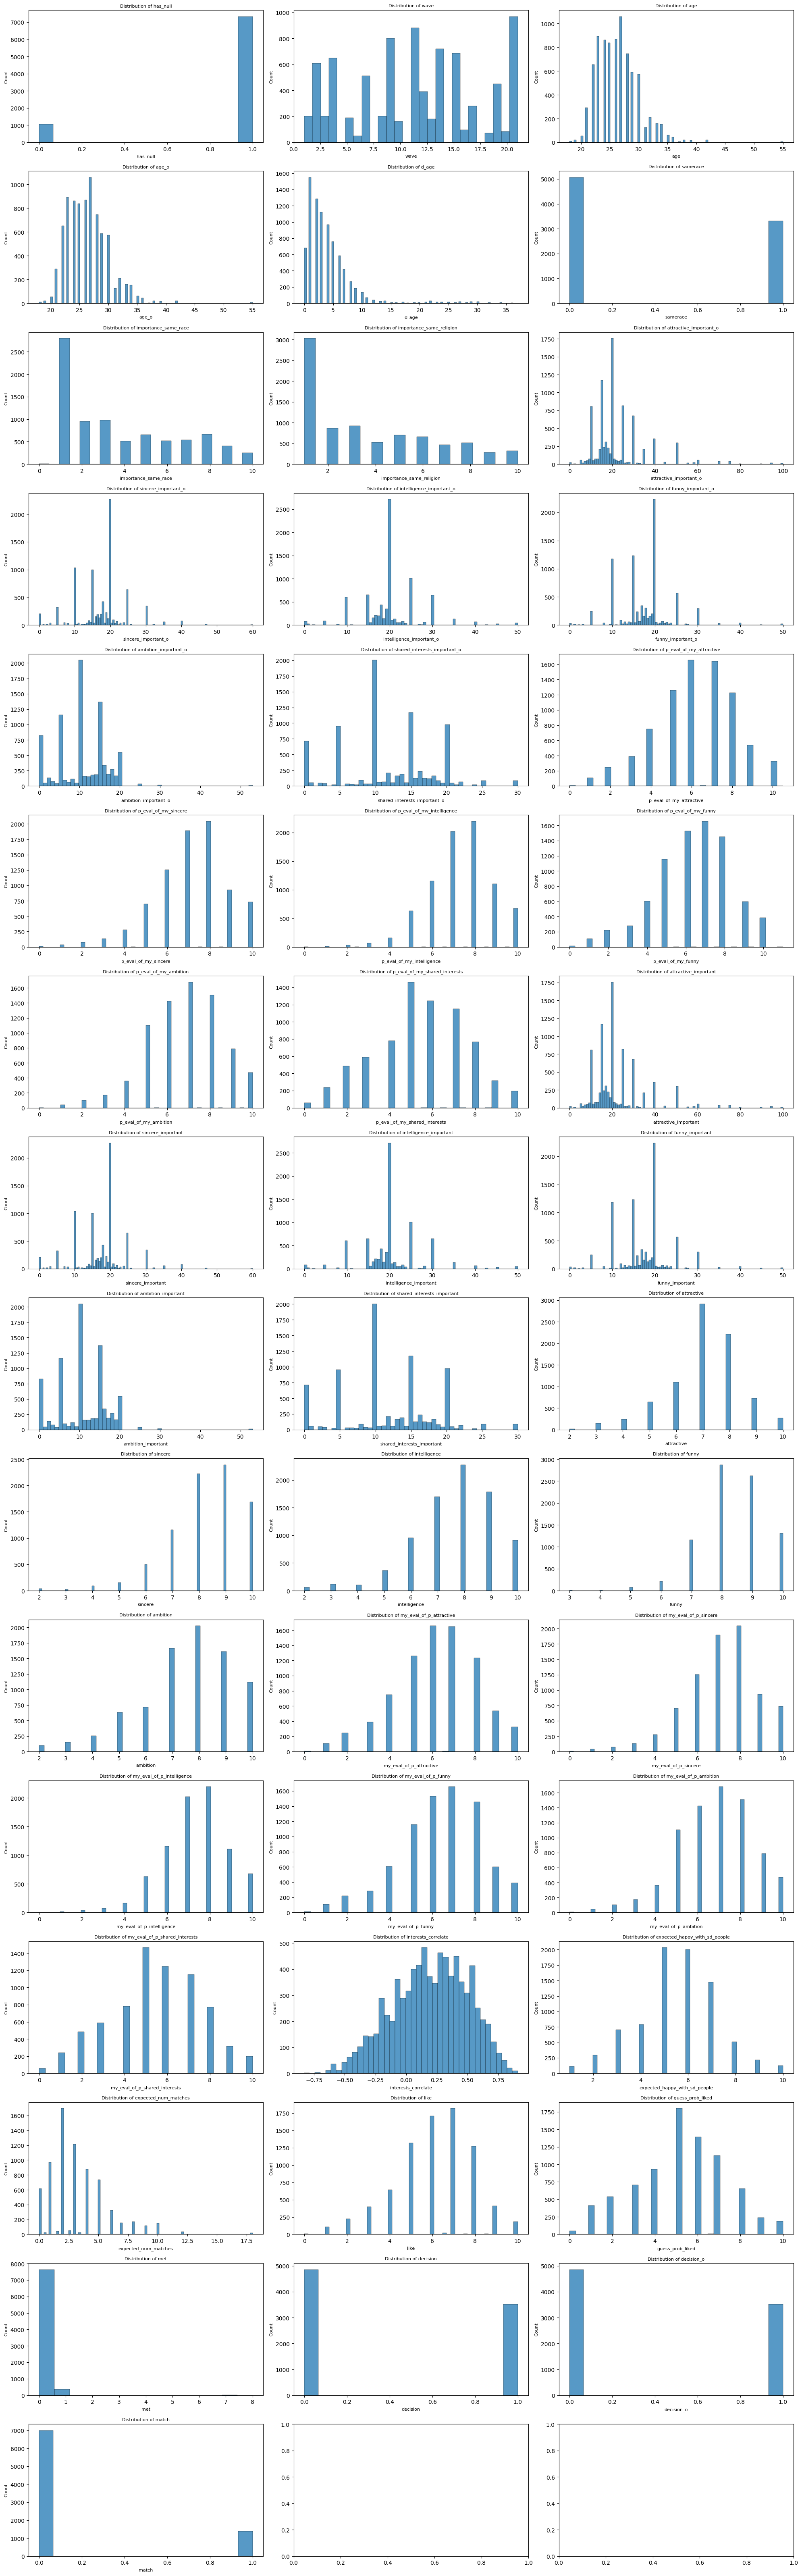

In [ ]:
plot_distributions(cleaned_df)

In [ ]:
cleaned_df[cleaned_df['met'] == 3]['met'].count()

np.int64(1)

In [ ]:
cleaned_df['has_null'].groupby(cleaned_df['has_null']).agg("count")
cleaned_df['has_null'].unique()

array([0, 1])

We've spotted some issues with data:\
1. Met should be represented as binary variable, but somehow there appear 1 record with met == 3, which cannot be. Since it is only 1 record we will simply remove it

In [ ]:
cleaned_df = cleaned_df.drop(cleaned_df[cleaned_df['met'] == 3].index)
cleaned_df[cleaned_df['met'] == 3]['met'].count()

np.int64(0)

## Analyse numerical data

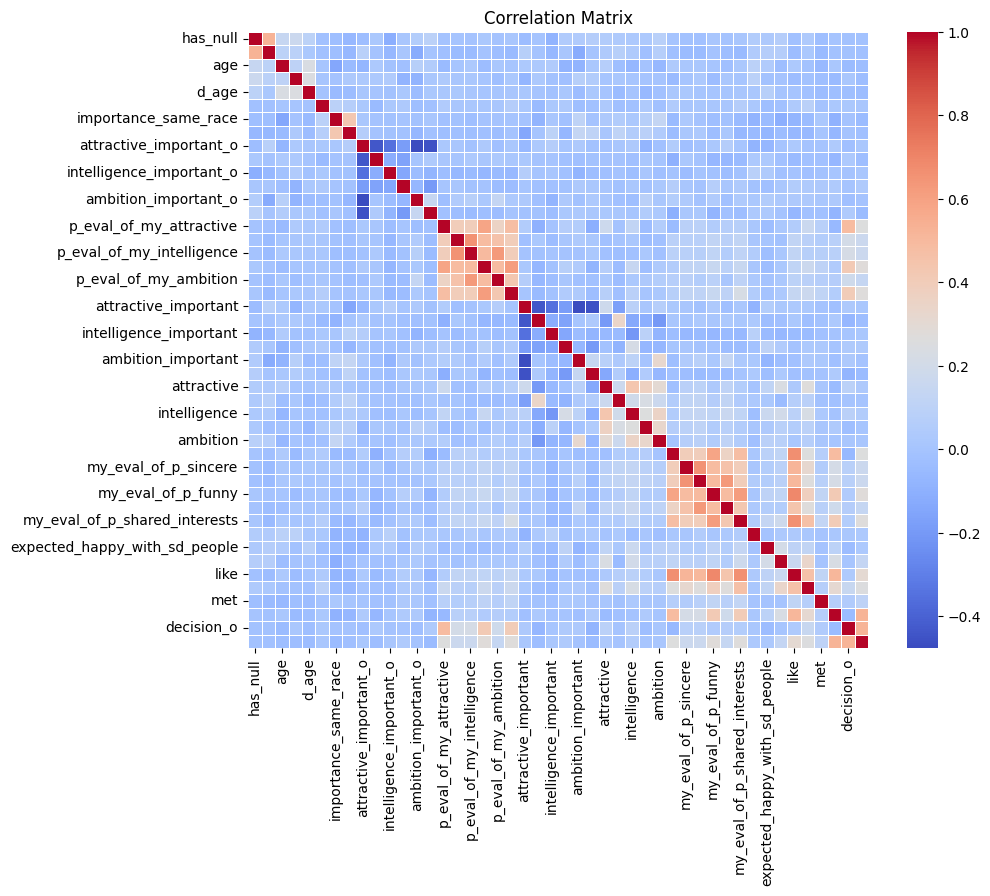

In [ ]:
numeric_columns = cleaned_df.select_dtypes(include=['number']).columns
correlation_matrix = cleaned_df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

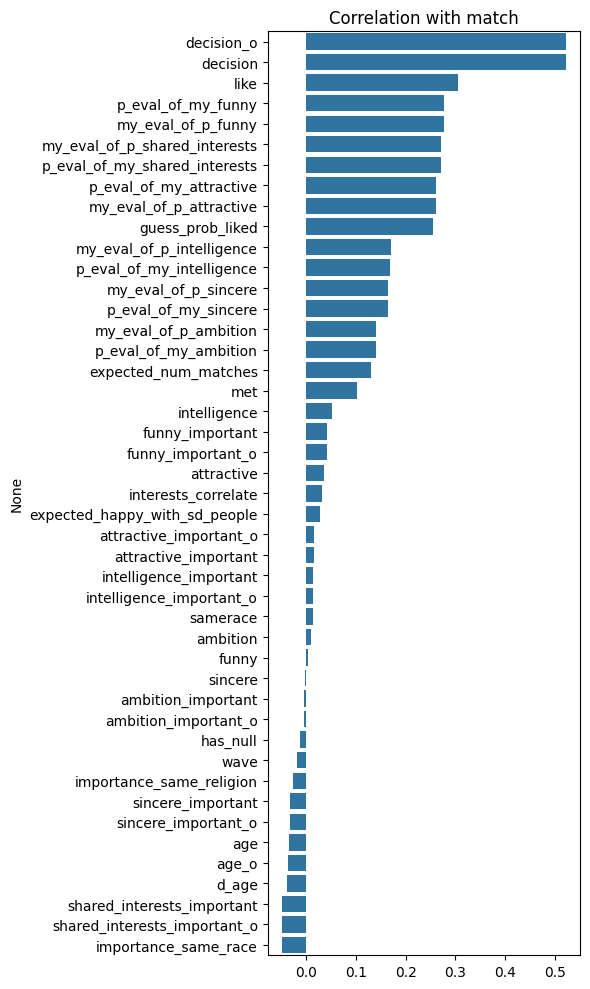

In [ ]:
numeric_columns = cleaned_df.select_dtypes(include=['number']).columns
corr_match = cleaned_df[numeric_columns].corr()['match'].drop('match').sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.barplot(x=corr_match.values, y=corr_match.index)
plt.title('Correlation with match')
plt.tight_layout()
plt.show()

In [ ]:
numerical_columns = cleaned_df.select_dtypes(include=['number'])
groupby_match = numerical_columns.groupby("match").agg("count")
groupby_match

,has_null,wave,age,age_o,d_age,samerace,importance_same_race,importance_same_religion,attractive_important_o,sincere_important_o,...,my_eval_of_p_ambition,my_eval_of_p_shared_interests,interests_correlate,expected_happy_with_sd_people,expected_num_matches,like,guess_prob_liked,met,decision,decision_o
match,,,,,,,,,,,,,,,,,,,,,
0,6997,6997,6920,6911,6997,6997,6933,6933,6923,6923,...,6363,6050,6869,6912,6059,6761,6702,6655,6997,6997
1,1380,1380,1362,1362,1380,1380,1365,1365,1365,1365,...,1302,1260,1350,1364,1145,1376,1366,1347,1380,1380


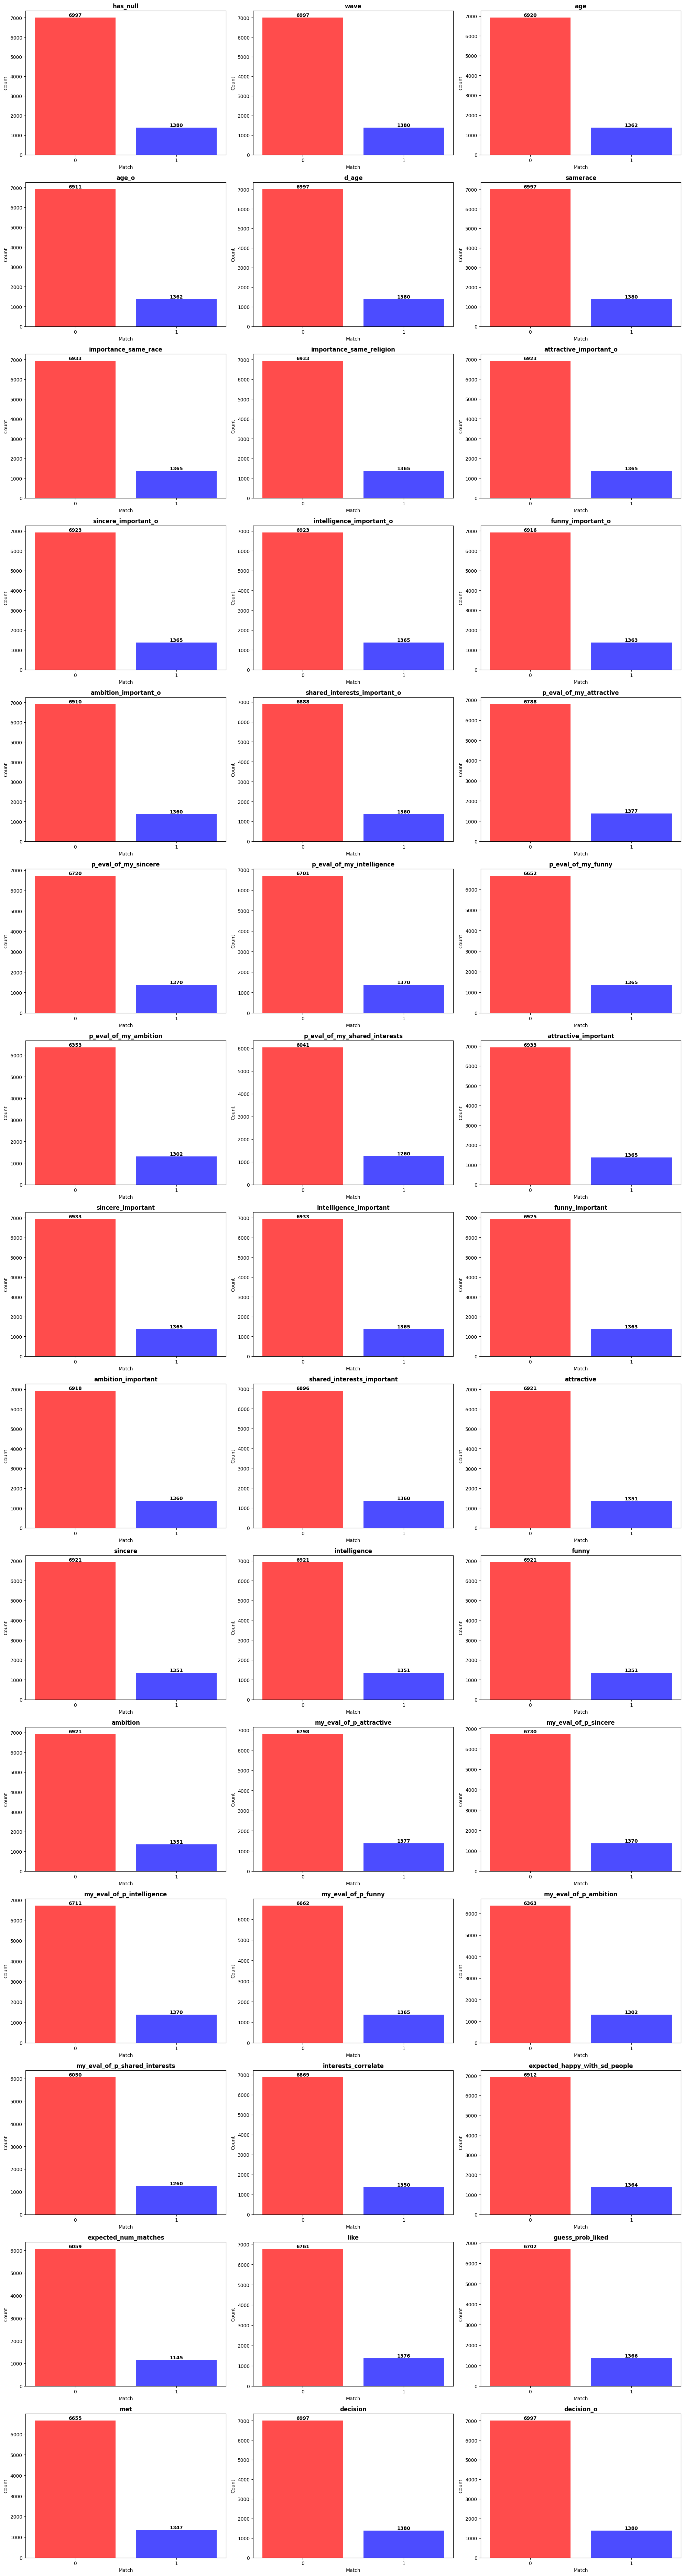

In [ ]:
if 'match' in numerical_columns.columns:
    plot_columns = numerical_columns.columns.drop('match')
else:
    plot_columns = numerical_columns.columns

n_cols = 3
n_rows = math.ceil(len(plot_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_columns):
    counts = cleaned_df.groupby('match')[col].apply(lambda x: x.notna().sum())

    bars = axes[i].bar(counts.index, counts.values, color=['red', 'blue'], alpha=0.7)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Match')
    axes[i].set_ylabel('Count')
    axes[i].set_xticks([0, 1])

    for bar, count in zip(bars, counts.values):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{count}', ha='center', va='bottom', fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Conclusional heatmap for each column

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 122 entries, has_null to match
dtypes: float64(56), int64(7), object(59)
memory usage: 7.8+ MB


## Corelation all available columns with match

we dont need has_null values columns

also all interest as movies or other we dont need becasue we have corelation interest column, but we will check them on heatmap

also all d_ columns we dont need because they are correlated with main columns and we can just dont use them(harder to process d columns for me)
(d_age a want to use because age is important for dating)(also from my udnerstanding we cant know d_ values before the date itself except for d_age)

also we dont want to use decision columns because they are will be get after date (we want to predict match before date)

also found a wave column, if we dont want to do a date we will not know wave

In [ ]:
column_to_drop = ['has_null', 'decision', 'decision_o', 'wave']
column_to_drop = column_to_drop + [col for col in cleaned_df.columns if col.startswith('d_')]
if 'd_age' in column_to_drop:
    column_to_drop.remove('d_age')
column_to_drop

['has_null',
 'decision',
 'decision_o',
 'wave',
 'd_d_age',
 'd_importance_same_race',
 'd_importance_same_religion',
 'd_attractive',
 'd_sincere',
 'd_intelligence',
 'd_funny',
 'd_ambition',
 'd_interests_correlate',
 'd_expected_happy_with_sd_people',
 'd_expected_num_interested_in_me',
 'd_expected_num_matches',
 'd_like',
 'd_guess_prob_liked']

In [ ]:
df_encoded_clean = data.copy().drop_duplicates()
for col in cleaned_df.select_dtypes(include=['object', 'category']).columns:
    df_encoded_clean[col] = cleaned_df[col].astype('category').cat.codes

df_encoded_clean = df_encoded_clean.drop(columns=column_to_drop)

corr = df_encoded_clean.corr(numeric_only=True)

<Axes: >

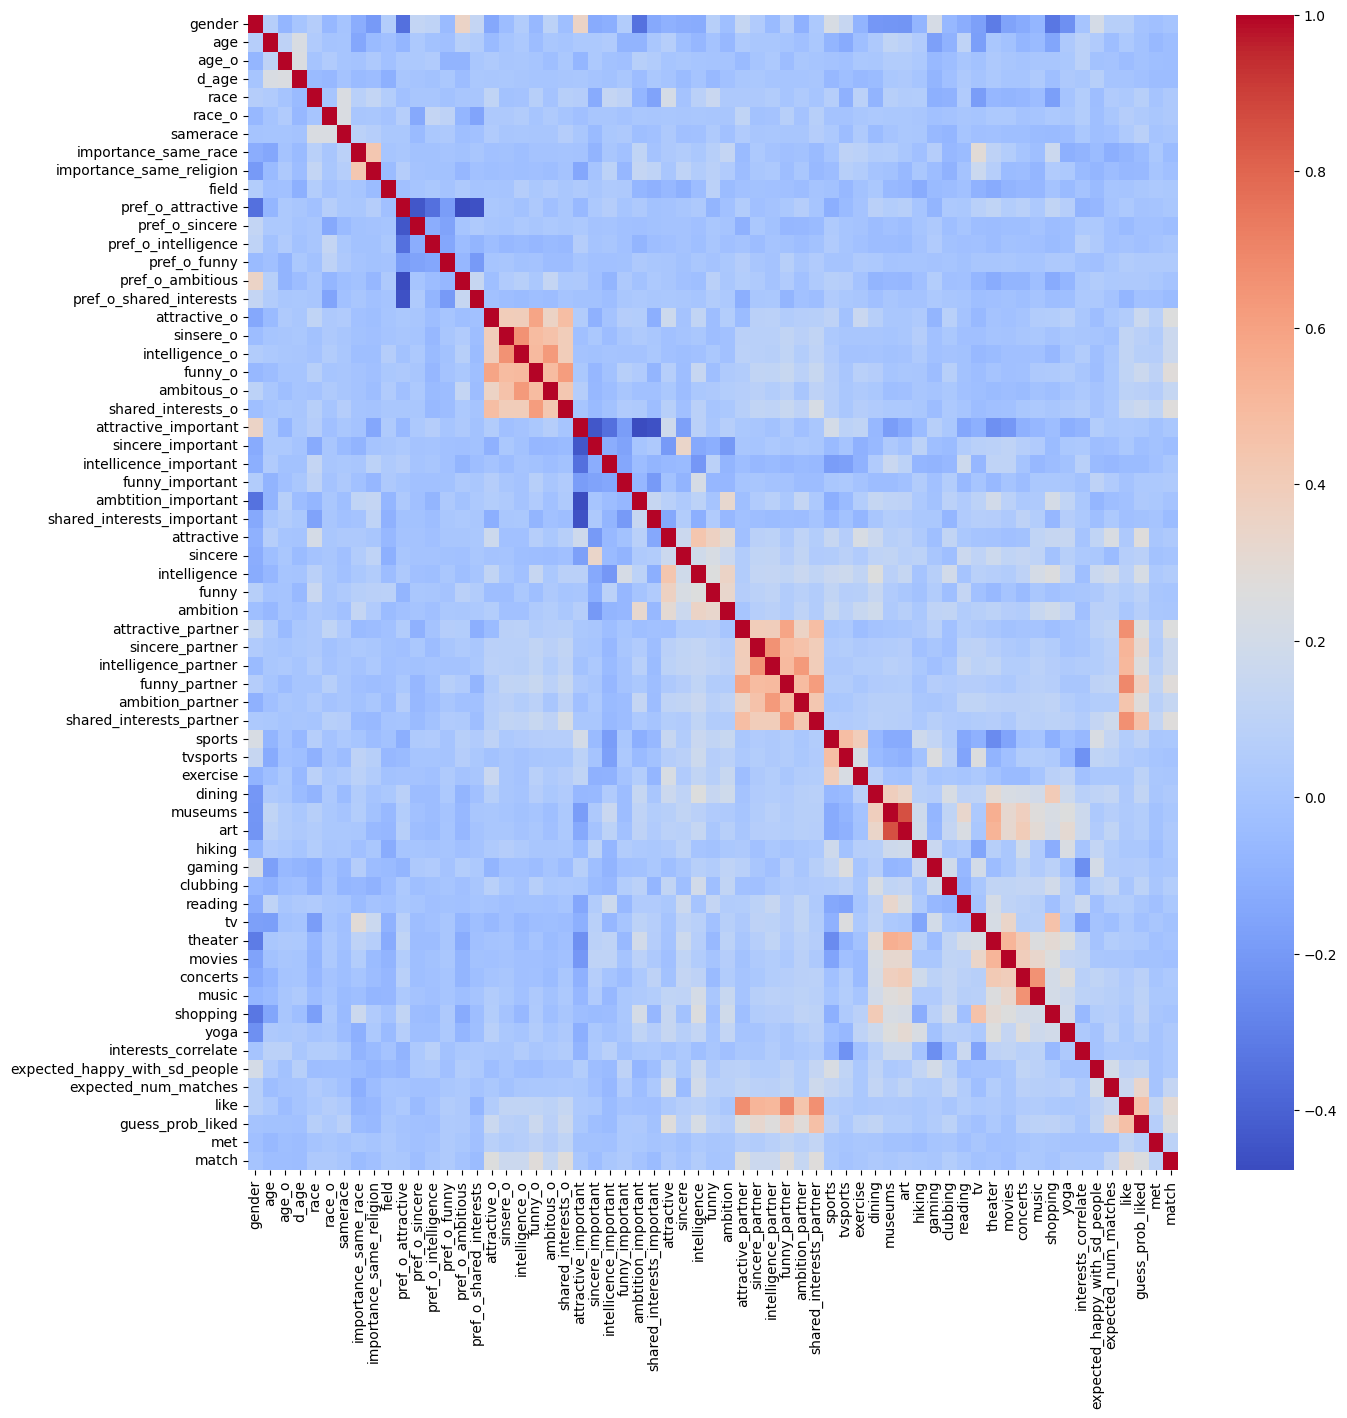

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(corr, cmap="coolwarm")

## Check what columns have high corelation with match

In [ ]:
match_corr = corr['match'].abs().sort_values(ascending=False)
match_corr.drop('match', inplace=True)

<Axes: xlabel='match', ylabel='None'>

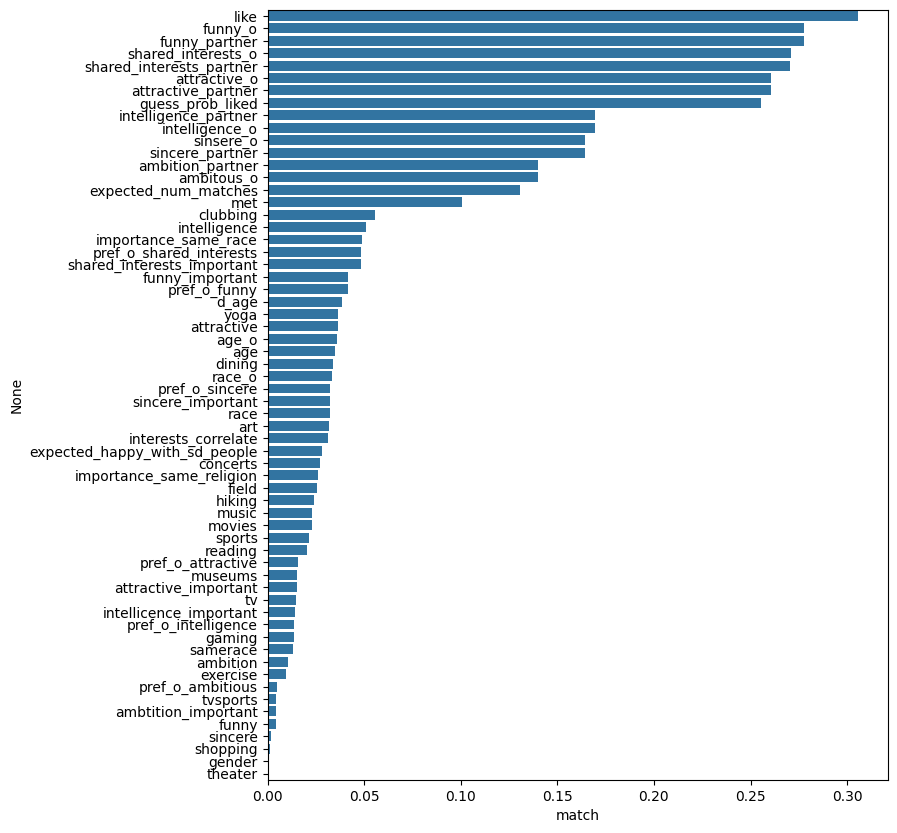

In [ ]:
plt.figure(figsize=(8, 10))
sns.barplot(x=match_corr, y=match_corr.index, orient='h')

## Correlation heatmap with top correlated columns

on this barplot we can see that most correlated columns with match, we will use them to check if they corelates beetween themselfs

In [ ]:
match_corr_top_columns = match_corr[match_corr > 0.1].index.tolist()
match_corr_top_columns

['like',
 'funny_o',
 'funny_partner',
 'shared_interests_o',
 'shared_interests_partner',
 'attractive_o',
 'attractive_partner',
 'guess_prob_liked',
 'intelligence_partner',
 'intelligence_o',
 'sinsere_o',
 'sincere_partner',
 'ambition_partner',
 'ambitous_o',
 'expected_num_matches',
 'met']

In [ ]:
corr = df_encoded_clean[match_corr_top_columns].corr(numeric_only=True)

<Axes: >

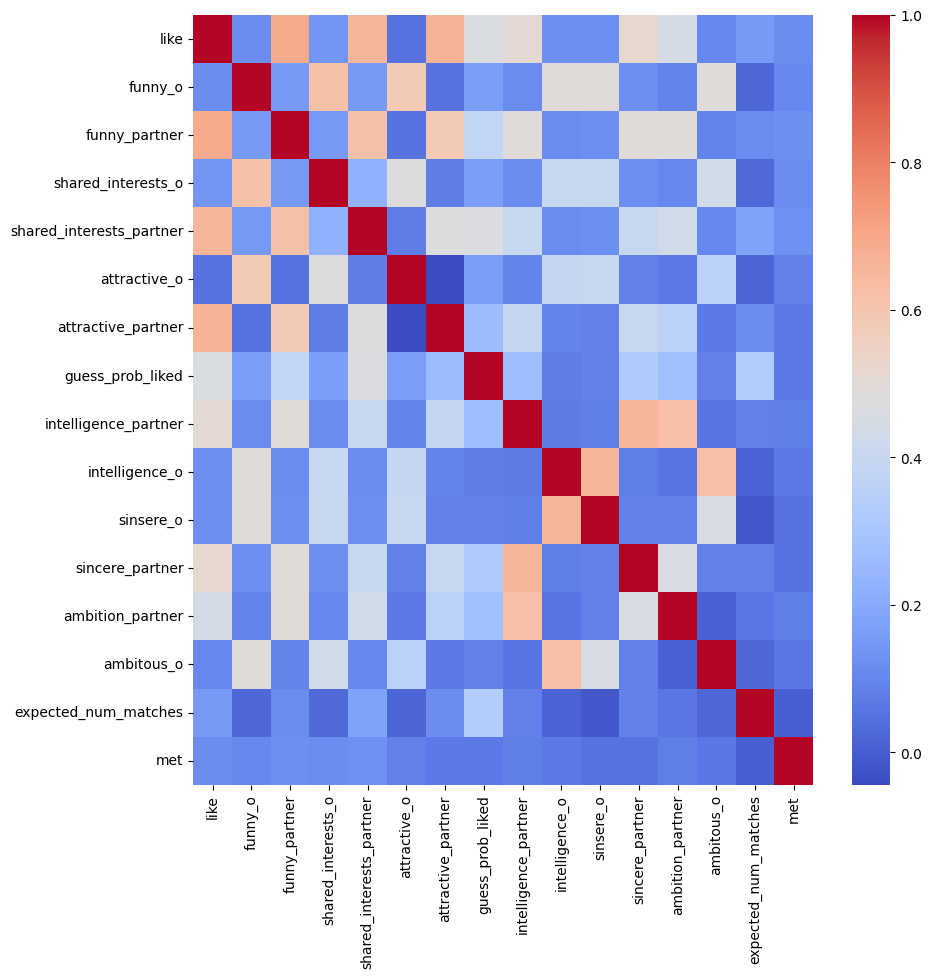

In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(corr, cmap="coolwarm")

## Data preprocessing and normalization pipeline

I don't want to keep features that have high correlation with each other, because this can lead to model overfitting and other problems. Therefore, I will select only those features that have high correlation with the target variable (match), but low correlation with each other.

Also better to drop _o columns because they are self reported and can be biased

Also we decided that all feature selection will be done with pipeline

creating pipeline for preprocessing and feature selection for our best correlation columns with match

In [ ]:
def preprocessing_pipeline(cat_cols: list[str], num_cols: list[str]):
    num_transformer = pipeline.Pipeline([
        ("imp", impute.SimpleImputer(strategy="median")),
        ("sc", preprocessing.StandardScaler())
    ])

    cat_transformer = pipeline.Pipeline([
        ("imp", impute.SimpleImputer(strategy="most_frequent")),
        ("oh", preprocessing.OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = compose.ColumnTransformer([
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ], remainder="drop")

    full_pipeline = pipeline.Pipeline([
        ("preprocessor", preprocessor),
    ])

    return full_pipeline

In [ ]:
num_cols = data.select_dtypes(include="number").columns.tolist()
cat_cols = data.select_dtypes(exclude="number").columns.tolist()

num_cols = [col for col in num_cols if col in match_corr_top_columns]
cat_cols = [col for col in cat_cols if col in match_corr_top_columns]


In [ ]:
chosen_cols = num_cols + cat_cols
len(num_cols), len(cat_cols), len(chosen_cols)

(16, 0, 16)

In [ ]:
chosen_cols

['attractive_o',
 'sinsere_o',
 'intelligence_o',
 'funny_o',
 'ambitous_o',
 'shared_interests_o',
 'attractive_partner',
 'sincere_partner',
 'intelligence_partner',
 'funny_partner',
 'ambition_partner',
 'shared_interests_partner',
 'expected_num_matches',
 'like',
 'guess_prob_liked',
 'met']

# Data split

We split to train and test data in ration 80/20

In [ ]:
x = data[chosen_cols]
y = data['match'].loc[x.index]

In [ ]:
x_train, x_tmp, y_train, y_tmp = model_selection.train_test_split(
    x, y, test_size=0.2, stratify=y
)
x_val, x_test, y_val, y_test = model_selection.train_test_split(
    x_tmp, y_tmp, test_size=0.5, stratify=y_tmp
)

In [ ]:
x_train

,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,expected_num_matches,like,guess_prob_liked,met
5357,6.0,3.0,5.0,4.0,4.0,1.0,7.0,8.0,NaN,7.0,5.0,4.0,2.0,5.0,4.0,0.0
7622,8.0,6.0,6.0,9.0,8.0,4.0,7.0,7.0,4.0,6.0,5.0,1.0,2.0,5.0,5.0,0.0
4821,7.0,9.0,9.0,7.0,7.0,4.0,6.0,10.0,8.0,6.0,5.0,NaN,2.0,6.0,1.0,0.0
2339,7.0,7.0,7.0,7.0,NaN,6.0,9.0,10.0,8.0,7.0,8.0,6.0,NaN,8.0,8.0,0.0
875,7.0,7.0,7.0,6.0,5.0,5.0,7.0,8.0,8.0,7.0,9.0,7.0,5.0,7.0,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3562,5.0,9.0,8.0,7.0,8.0,5.0,8.0,9.0,8.0,8.0,8.0,NaN,1.0,8.0,8.0,0.0
5391,8.0,10.0,10.0,7.0,10.0,6.0,7.0,7.0,8.0,8.0,9.0,8.0,4.0,7.5,6.0,0.0
3341,4.0,7.0,6.0,4.0,4.0,4.0,9.0,7.0,7.0,7.0,6.0,7.0,1.0,8.0,5.0,0.0
3233,7.0,10.0,8.0,6.0,7.0,2.0,5.0,6.0,8.0,5.0,5.0,5.0,NaN,5.0,5.0,0.0


In [ ]:
y_test

,match
3777,1
6147,0
8301,0
750,0
5310,0
...,...
8152,0
3798,0
8355,0
2095,0


# Train data preprocessing

In [ ]:
preprocessor = preprocessing_pipeline(cat_cols, num_cols)
x_train_preprocessed = preprocessor.fit_transform(x_train, y_train)
x_test_preprocessed = preprocessor.transform(x_test)
x_val_preprocessed = preprocessor.transform(x_val)

In [ ]:
x_train_preprocessed

array([[-0.09662024, -2.43076081, -1.57323236, ..., -0.6186187 ,
        -0.57977765, -0.16795468],
       [ 0.94328473, -0.67583687, -0.90619856, ..., -0.6186187 ,
        -0.10080448, -0.16795468],
       [ 0.42333225,  1.07908707,  1.09490284, ..., -0.06664531,
        -2.01669715, -0.16795468],
       ...,
       [-1.1365252 , -0.09086222, -0.90619856, ...,  1.03730148,
        -0.10080448, -0.16795468],
       [ 0.42333225,  1.66406172,  0.42786904, ..., -0.6186187 ,
        -0.10080448, -0.16795468],
       [ 0.42333225,  1.07908707,  1.09490284, ...,  0.48532808,
         0.37816868, -0.16795468]])

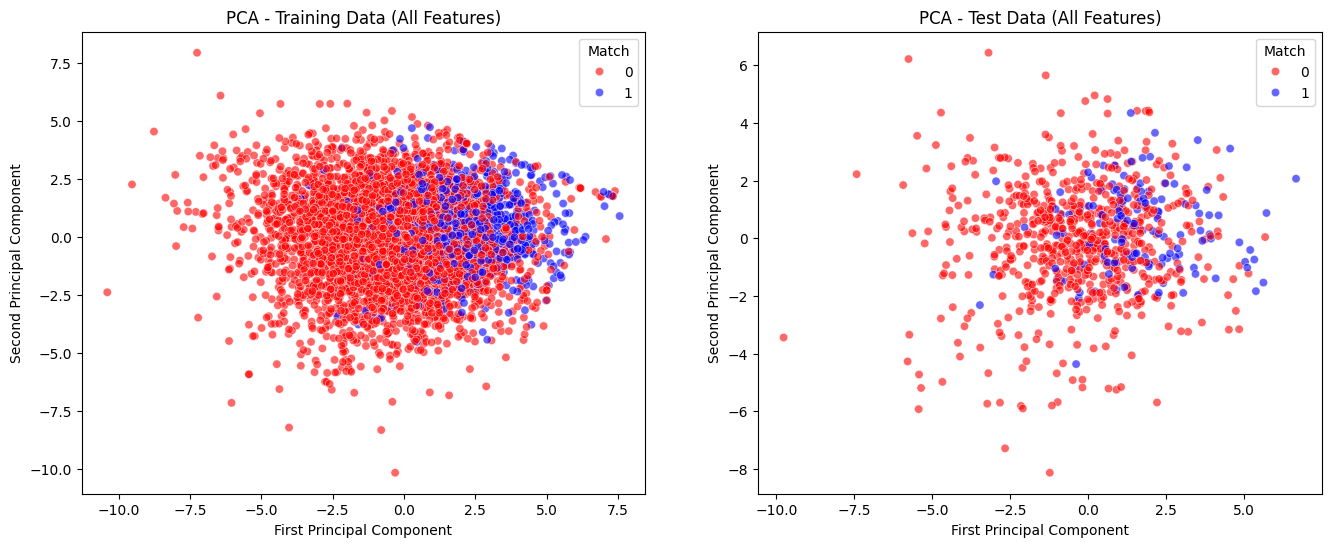

In [ ]:
pca_all = decomposition.PCA(n_components=2)
x_train_pca_all = pca_all.fit_transform(x_train_preprocessed)
x_test_pca_all = pca_all.transform(x_test_preprocessed)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=x_train_pca_all[:, 0], y=x_train_pca_all[:, 1], hue=y_train,
                palette=['red', 'blue'], alpha=0.6, ax=axes[0])
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].set_title('PCA - Training Data (All Features)')
axes[0].legend(title='Match')

sns.scatterplot(x=x_test_pca_all[:, 0], y=x_test_pca_all[:, 1], hue=y_test,
                palette=['red', 'blue'], alpha=0.6, ax=axes[1])
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
axes[1].set_title('PCA - Test Data (All Features)')
axes[1].legend(title='Match')

# Wanddb configuration

In [ ]:
# os.environ['WANDB_API_KEY'] = 'your_wandb_api_key_here'

In [142]:
wandb_entity = "zneus_speeddating"
wandb_project = "zneus2025"
train_configs = [
    # {
    #     "name": f"relu_relu_sigm_{time.strftime('%d_%m_%Y_%H%M')}_lr0.0001_bs64_h32_8_dr0.05",
    #     "learning_rate": 0.0001,
    #     "batch_size": 64,
    #     "epochs": 15,
    #     "hidden_dims": [32, 8, 4],
    #     "dropout": 0.05,
    #     "activations": ["RELU", "RELU", "SIGM"],
    # },
    # {
    #     "name": f"RELU_RELU_sigm_{time.strftime('%d_%m_%Y_%H%M')}_lr0.001_bs32_h32_16_dr0.2",
    #     "learning_rate": 0.001,
    #     "batch_size": 32,
    #     "epochs": 15,
    #     "hidden_dims": [32, 16, 8],
    #     "dropout": 0.2,
    #     "activations": ["RELU", "RELU", "SIGM"],
    # },
    {
        "name": f"1relu_relu_sigm_{time.strftime('%d_%m_%Y_%H%M')}_lr0.013_bs128_h32_16_8_dr0.12",
        "learning_rate": 0.003,
        "batch_size": 128,
        "epochs": 50,
        "hidden_dims": [32, 16, 8],
        "dropout": 0.2,
        "activations": ["RELU", "RELU", "SIGM"],
    },
    {
        "name": f"2relu_relu_tanh_{time.strftime('%d_%m_%Y_%H%M')}_lr0.001_bs64_h16_8_8_dr0.15",
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs": 50,
        "hidden_dims": [16, 8, 8],
        "dropout": 0.2,
        "activations": ["RELU", "RELU", "TANH"],
    },
    {
        "name": f"3RELU_RELU_Relu_sigm_{time.strftime('%d_%m_%Y_%H%M')}_lr0.005_bs64_h16_8_4_4_1dr0.2",
        "learning_rate": 0.03,
        "batch_size": 512,
        "epochs": 50,
        "hidden_dims": [16, 8, 4, 4],
        "dropout": 0.2,
        "activations": ["RELU", "RELU", "RELU", "SIGM"],
    },

    {
        "name": f"4RELU_sigm_{time.strftime('%d_%m_%Y_%H%M')}_lr0.004_bs128_h32_8_1dr0.13",
        "learning_rate": 0.004,
        "batch_size": 128,
        "epochs": 50,
        "hidden_dims": [16, 8],
        "dropout": 0.2,
        "activations": ["RELU", "SIGM"],
    },
    {
        "name": f"5RELU_sigm_{time.strftime('%d_%m_%Y_%H%M')}_lr0.001_bs512_h32_16_1dr0.05",
        "learning_rate": 0.0001,
        "batch_size": 512,
        "epochs": 50,
        "hidden_dims": [32, 8],
        "dropout": 0.12,
        "activations": ["RELU", "SIGM"],
    },
]

## Train MLP models with Weights & Biases

## Define what train and test data we will use for training MLP models

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch import nn, optim
if not isinstance(x_train_preprocessed, np.ndarray):
    train_features = torch.tensor(x_train_preprocessed.toarray(), dtype=torch.float32)
    test_features = torch.tensor(x_test_preprocessed.toarray(), dtype=torch.float32)
    val_features = torch.tensor(x_val_preprocessed.toarray(), dtype=torch.float32)
else:
    train_features = torch.tensor(x_train_preprocessed, dtype=torch.float32)
    test_features = torch.tensor(x_test_preprocessed, dtype=torch.float32)
    val_features = torch.tensor(x_val_preprocessed, dtype=torch.float32)

train_targets = torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)
test_targets = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)
val_targets = torch.tensor(y_val.to_numpy(), dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(train_features, train_targets)
val_dataset = TensorDataset(val_features, val_targets)
test_dataset = TensorDataset(test_features, test_targets)

device = 'cuda'
# device = 'cpu'

regular train functions that are used for training MLP models and evaluating them

because we gave binary classification problem we will use BCEWithLogitsLoss as loss function

In [ ]:
# def train_epoch(model: nn.Module, dataloader: DataLoader, criterion: nn.Module, optimizer: optim.Optimizer, device: str):
#     model.train()
#     total_loss = 0.0
#     for features, targets in dataloader:
#         features, targets = features.to(device), targets.to(device)
#         optimizer.zero_grad()
#         logits = model(features)
#         loss = criterion(logits, targets)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item() * targets.size(0)
#     return total_loss / len(dataloader.dataset) # type: ignore

# def evaluate(model: nn.Module, dataloader: DataLoader, criterion: nn.Module, device: str):
#     model.eval()
#     total_loss = 0.0
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for features, targets in dataloader:
#             features, targets = features.to(device), targets.to(device)
#             logits = model(features)
#             loss = criterion(logits, targets)
#             total_loss += loss.item() * targets.size(0)
#             preds = torch.sigmoid(input=logits)
#             correct += ((preds >= 0.5) == (targets >= 0.5)).sum().item()
#             total += targets.size(0)
#     return total_loss / len(dataloader.dataset), correct / total # type: ignore

In [ ]:
# os.environ['WANDB_API_KEY'] = "api key"

## Training and evaluating MLP

In [ ]:
# from model import MLP, ActivationFunctions
# import torch
# from torch.utils.data import DataLoader
# import wandb

# # best_val_loss = float("inf")
# # best_state = None

# for cfg in train_configs:

#     best_val_loss = float("inf")
#     best_state = None

#     run = wandb.init(project=wandb_project, config=cfg, name=cfg["name"])
#     config = wandb.config
#     hidden_dims = tuple(config.hidden_dims)
#     activation_layers = tuple(ActivationFunctions[name] for name in config.activations)
#     model = MLP(
#         input_dim=train_features.shape[1],
#         hidden_dims=hidden_dims,
#         activations=activation_layers,
#         dropout=config.dropout,
#     ).to(device)

#     optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
#     criterion = torch.nn.BCEWithLogitsLoss()
#     train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
#     val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

#     for epoch in range(config.epochs):
#         # model.train()
#         train_loss = model.train_epoch( train_loader, criterion, optimizer, device)
#         model.eval()
#         with torch.no_grad():
#             val_loss, val_acc = model.evaluate( val_loader, criterion, device)
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#         run.log({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss, "val_accuracy": val_acc})

#     assert best_state is not None

# # TODO: use validation data set also, update evaluate function, also move evaluate and train function to model.py

#     test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)
#     model.load_state_dict(best_state)

#     model.eval()
#     with torch.no_grad():
#         test_loss, test_acc = model.evaluate( test_loader, criterion, device)
#     run.log({"final_test_loss": test_loss, "final_test_accuracy": test_acc})
#     run.finish()


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
final_test_accuracy,▁
final_test_loss,▁
train_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▂▁▂▁▁▁
epoch,50
final_test_accuracy,0.83532
final_test_loss,0.32302
train_loss,0.31497
val_accuracy,0.83532


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
final_test_accuracy,▁
final_test_loss,▁
train_loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▃▅▂▄▅▅▅▅▂▅█▅▅▅▅▆▆▇▅▅▅▅▅▅
val_loss,█▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,50
final_test_accuracy,0.84248
final_test_loss,0.31828
train_loss,0.32526
val_accuracy,0.84368


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
final_test_accuracy,▁
final_test_loss,▁
train_loss,█▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,50
final_test_accuracy,0.83532
final_test_loss,0.33834
train_loss,0.35195
val_accuracy,0.83532


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
final_test_accuracy,▁
final_test_loss,▁
train_loss,█▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▄▄▄▇▆▄▆▆▇█▅▇▇▇▆▆
val_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,50
final_test_accuracy,0.83532
final_test_loss,0.32259
train_loss,0.31726
val_accuracy,0.84845


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
final_test_accuracy,▁
final_test_loss,▁
train_loss,██▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
val_accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,████▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
epoch,50
final_test_accuracy,0.83532
final_test_loss,0.44186
train_loss,0.44387
val_accuracy,0.83532
